# Lecture 6: Null Hypothesis Testing and Power

## Contents

- [6.1 Effect sizes](#section-61)
- [6.2 Hypothesis tests](#section-62)
- [6.3 Bayes factor](#section-63)
- [6.4 ROPE and HDI test](#section-64)
- [6.5 Significance](#section-65)
- [6.6 Basics of statistical reporting](#section-66)
- [6.7 Power](#section-67)
- [6.8 Pre-hoc and post-hoc power](#section-68)
- [6.9 Frequentist methods](#section-69)
- [6.10 Comparing two groups](#section-610)


## Setup


### Data access policy
This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Lecture 6 uses the Bartos et al. coin-flip aggregate data from the course repository and the New York City heart-attack hospital data from the ProbBayes repository.

The required data filenames and source URLs are listed in the next cell. For each file, the notebook searches in likely local data directories, including the public course-data directory. If a required file is not found locally, the notebook downloads it into `.` from the listed source URL.


In [192]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


if IS_COLAB:
    ensure_package("preliz")
    ensure_package("statsmodels")
    ensure_package("pymc")
    ensure_package("arviz")
    ensure_package("arviz-plots", "arviz_plots")

print("Colab detected:", IS_COLAB)


Colab detected: False


### Required data files


In [ ]:
REQUIRED_DATA_FILES = {
    "bartos_coin_flips_agg.csv": "https://raw.githubusercontent.com/opherdonchin/StatisticsCourse_36714361/main/public_content/Data/bartos_coin_flips_agg.csv",
    "DeathHeartAttackDataNYCfull.txt": "https://raw.githubusercontent.com/bayesball/ProbBayes/master/data/DeathHeartAttackDataNYCfull.txt",
}


### Resolve required data files


In [194]:
from pathlib import Path
import urllib.request

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("public_content") / "Data",
    Path("..") / "data",
    Path("..") / "Data",
    Path("..") / "public_content" / "Data",
    Path("..") / ".." / "Data",
]


def find_existing_file(filename):
    for directory in SEARCH_DIRS:
        candidate = (directory / filename).resolve()
        if candidate.exists():
            return candidate
    return None


def download_required_file(filename, url):
    destination = (Path(".") / filename).resolve()
    urllib.request.urlretrieve(url, destination)
    return destination


DATA_FILE_PATHS = {}
for filename, url in REQUIRED_DATA_FILES.items():
    existing = find_existing_file(filename)
    DATA_FILE_PATHS[filename] = existing or download_required_file(filename, url)


def read_required_csv(filename, **kwargs):
    import pandas as pd

    return pd.read_csv(DATA_FILE_PATHS[filename], **kwargs)


print("Resolved data files:", {name: str(path) for name, path in DATA_FILE_PATHS.items()})


Resolved data files: {'bartos_coin_flips_agg.csv': 'D:\\Repositories\\StatisticalComputationAndAnalysis\\Data\\bartos_coin_flips_agg.csv', 'DeathHeartAttackDataNYCfull.txt': 'D:\\Repositories\\StatisticalComputationAndAnalysis\\Notebooks\\DeathHeartAttackDataNYCfull.txt'}


### Do imports and settings


In [195]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

import pymc as pm
import arviz as az
import arviz_plots as azp
import preliz as pz

from IPython.display import display, Math, Markdown


<a id="section-61"></a>
## 6.1 Effect sizes

The null model for the coin examples is exact fairness, $	heta_0=0.5$. We compare measured effects with that null value on raw and normalized scales.


In [196]:
coin_flips = read_required_csv("bartos_coin_flips_agg.csv")

coin_flips["N"] = coin_flips["N_start_heads_up"] + coin_flips["N_start_tails_up"]
coin_flips["heads_total"] = coin_flips["heads_heads"] + coin_flips["tails_heads"]
coin_flips["tails_total"] = coin_flips["N"] - coin_flips["heads_total"]
coin_flips["prop_heads"] = coin_flips["heads_total"] / coin_flips["N"]
coin_flips["prop_start_heads"] = coin_flips["N_start_heads_up"] / coin_flips["N"]

coin_flips.head()


,heads_heads,tails_heads,N_start_heads_up,N_start_tails_up,person,coin,N,heads_total,tails_total,prop_heads,prop_start_heads
0,244,240,485,515,frantisekB,20DEM-silver,1000,484,516,0.4840,0.4850
1,260,245,505,495,frantisekB,1CZK,1000,505,495,0.5050,0.5050
2,209,260,469,531,frantisekB,5CZK,1000,469,531,0.4690,0.4690
3,530,495,1021,979,frantisekB,0.25USD,2000,1025,975,0.5125,0.5105
4,533,507,1039,961,frantisekB,10CZK,2000,1040,960,0.5200,0.5195


In [197]:
person = "TianqiPeng"
coin = "0.20EUR"

candidate = coin_flips.loc[
    (coin_flips["person"] == person) & (coin_flips["coin"] == coin)
].squeeze()

heads = int(candidate["heads_total"])
tails = int(candidate["tails_total"])
n_tosses = int(candidate["N"])

naive_summary = pd.DataFrame(
    {
        "quantity": ["heads", "tails", "total tosses", "heads proportion", "raw effect: heads proportion - 0.5"],
        "value": [heads, tails, n_tosses, heads / n_tosses, heads / n_tosses - 0.5],
    }
)

naive_summary


,quantity,value
0,heads,445.000
1,tails,555.000
2,total tosses,1000.000
3,heads proportion,0.445
4,raw effect: heads proportion - 0.5,-0.055


For probabilities, the raw effect size is usually just the difference of probabilities:

$$
\Delta_{coin} = \hat{\theta} - 0.5
$$

Other scales compare the observed heads probability to the exact-fairness value, $\theta_0 = 0.5$:

$$
RR = \frac{\hat{\theta}}{0.5}
$$

$$
OR = \frac{\hat{\theta}/(1-\hat{\theta})}{0.5/(1-0.5)}
$$

$$
\log(OR) = \log\left(\frac{\hat{\theta}/(1-\hat{\theta})}{0.5/(1-0.5)}\right)
$$

A standardized effect size for probabilities is Cohen's $h$:

$$
h = 2\arcsin\!\big(\sqrt{\hat{\theta}}\big) - 2\arcsin\!\big(\sqrt{0.5}\big)
$$

Negative values of $\Delta_{coin}$, $\log(OR)$, and $h$ mean fewer heads than expected under exact fairness. Values of $RR$ and $OR$ below 1 mean the same thing.


The same raw and normalized effect sizes can look very different depending on how much data we have. The next table keeps the direction fixed: all three examples have fewer heads than expected under exact fairness.


Build the three coin examples and calculate raw and normalized effect sizes.


Create a small Markdown table helper.


In [ ]:
from IPython.display import Markdown


def markdown_table(dataframe, float_digits=2):
    formatted = dataframe.copy()
    for column in formatted.select_dtypes(include="number").columns:
        if column in ["$N$", "heads", "tails"]:
            formatted[column] = formatted[column].map("{:.0f}".format)
        else:
            formatted[column] = formatted[column].map(f"{{:.{float_digits}f}}".format)

    header = "| " + " | ".join(formatted.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(formatted.columns)) + " |"
    rows = [
        "| " + " | ".join(str(value) for value in row) + " |"
        for row in formatted.to_numpy()
    ]
    return "\n".join([header, separator, *rows])


Calculate effect-size summaries for three coin examples.


In [ ]:
effect_size_examples = pd.DataFrame(
    [
        {"person": "EJ", "coin": "50CZK"},
        {"person": "TianqiPeng", "coin": "0.20EUR"},
        {"person": "davidV", "coin": "0.10EUR"},
    ]
)

effect_size_examples = effect_size_examples.merge(
    coin_flips,
    on=["person", "coin"],
    how="left",
    validate="one_to_one",
)

effect_size_examples["theta_hat"] = effect_size_examples["heads_total"] / effect_size_examples["N"]
effect_size_examples["delta"] = effect_size_examples["theta_hat"] - 0.5
effect_size_examples["risk_ratio"] = effect_size_examples["theta_hat"] / 0.5
effect_size_examples["odds_ratio"] = (
    effect_size_examples["theta_hat"] / (1 - effect_size_examples["theta_hat"])
) / (0.5 / (1 - 0.5))
effect_size_examples["log_odds_ratio"] = np.log(effect_size_examples["odds_ratio"])
effect_size_examples["Cohen_h"] = (
    2 * np.arcsin(np.sqrt(effect_size_examples["theta_hat"]))
    - 2 * np.arcsin(np.sqrt(0.5))
)

comparison_table = effect_size_examples.rename(
    columns={
        "person": "person",
        "coin": "coin",
        "N": "$N$",
        "heads_total": "heads",
        "tails_total": "tails",
        "theta_hat": r"$\hat{\theta}$",
        "delta": r"$\hat{\Delta}$",
        "risk_ratio": "$RR$",
        "odds_ratio": "$OR$",
        "log_odds_ratio": r"$\log(OR)$",
        "Cohen_h": "$h$",
    }
)[
    [
        "person",
        "coin",
        "$N$",
        "heads",
        "tails",
        r"$\hat{\theta}$",
        r"$\hat{\Delta}$",
        "$RR$",
        "$OR$",
        r"$\log(OR)$",
        "$h$",
    ]
]


Display the effect-size table.


In [ ]:
display(Markdown(markdown_table(comparison_table)))


In [199]:
from IPython.display import Markdown

theta_hat = heads / n_tosses
delta_hat = theta_hat - 0.5
risk_ratio = theta_hat / 0.5
odds_ratio = (theta_hat / (1 - theta_hat)) / (0.5 / (1 - 0.5))
log_odds_ratio = np.log(odds_ratio)
cohens_h = 2 * np.arcsin(np.sqrt(theta_hat)) - 2 * np.arcsin(np.sqrt(0.5))

summary_table = pd.DataFrame(
    {
        "effect size": [
            "$\\hat{\\theta}$",
            "$\\hat{\\Delta}$",
            "$RR$",
            "$OR$",
            "$\\log(OR)$",
            "$h$",
        ],
        "value": [
            theta_hat,
            delta_hat,
            risk_ratio,
            odds_ratio,
            log_odds_ratio,
            cohens_h,
        ],
    }
)

display(Markdown(markdown_table(summary_table)))


| effect size | value |
| --- | --- |
| $\hat{\theta}$ | 0.45 |
| $\hat{\Delta}$ | -0.05 |
| $RR$ | 0.89 |
| $OR$ | 0.80 |
| $\log(OR)$ | -0.22 |
| $h$ | -0.11 |

<a id="section-62"></a>
## 6.2 Hypothesis tests

A hypothesis test asks whether the observed data make the null model difficult to believe. The amount of data matters as much as the measured effect.


The fair-coin value, $\theta=0.5$, is still plausible only if the posterior keeps substantial density there.

For the three examples below, we fit the same beta-binomial model:

$$
\theta \sim \textrm{Beta}(\alpha_0, \beta_0)
$$

$$
H \sim \textrm{Binomial}(N, \theta)
$$

The prior is centered on exact fairness. We use PyMC to sample the posterior and ArviZ to plot it.


In [200]:
prior_mu = 0.5
prior_sigma = 0.05
prior_concentration = prior_mu * (1 - prior_mu) / prior_sigma**2 - 1
prior_alpha = prior_mu * prior_concentration
prior_beta = (1 - prior_mu) * prior_concentration

COIN_MODEL_DRAWS = 2000
COIN_MODEL_TUNE = 1000
COIN_MODEL_CHAINS = 4
COIN_MODEL_CORES = 1
COIN_PRIOR_DRAWS = 4000
HDI_MASS = 0.94
SIGNIFICANCE_ALPHA = 0.06


Fit the same beta-binomial model to each coin example.


Define and fit the coin model for each example.


In [ ]:
def sample_coin_model(row, random_seed):
    with pm.Model() as model:
        theta = pm.Beta("theta", alpha=prior_alpha, beta=prior_beta)
        pm.Binomial(
            "heads_observed",
            n=int(row["N"]),
            p=theta,
            observed=int(row["heads_total"]),
        )
        idata = pm.sample(
            draws=COIN_MODEL_DRAWS,
            tune=COIN_MODEL_TUNE,
            chains=COIN_MODEL_CHAINS,
            cores=COIN_MODEL_CORES,
            random_seed=random_seed,
            target_accept=0.95,
            progressbar=False,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": False},
        )
        prior_idata = pm.sample_prior_predictive(
            draws=COIN_PRIOR_DRAWS,
            var_names=["theta"],
            random_seed=random_seed + 10_000,
            return_inferencedata=True,
        )
    idata.extend(prior_idata)
    return model, idata


posterior_examples = effect_size_examples.copy()
posterior_examples["example_id"] = posterior_examples["person"] + " / " + posterior_examples["coin"]

coin_models = {}
coin_idatas = {}
for idx, example in posterior_examples.iterrows():
    model, idata = sample_coin_model(example, random_seed=367_143 + idx)
    coin_models[example["example_id"]] = model
    coin_idatas[example["example_id"]] = idata

    theta_samples = idata.posterior["theta"].values.ravel()
    posterior_hdi = az.hdi(theta_samples, hdi_prob=HDI_MASS)
    posterior_examples.loc[idx, "posterior_mean"] = theta_samples.mean()
    posterior_examples.loc[idx, "posterior_low"] = posterior_hdi[0]
    posterior_examples.loc[idx, "posterior_high"] = posterior_hdi[1]


Plot the posterior distribution for each example.


In [ ]:
for _, example in posterior_examples.iterrows():
    idata = coin_idatas[example["example_id"]]
    theta_samples = idata.posterior["theta"].values.ravel()

    fig, ax = plt.subplots(figsize=(8, 4))
    az.plot_dist(theta_samples, kind="kde", ax=ax, show=False)
    ax.axvline(example["theta_hat"], color="black", linestyle=":", label=r"$\hat{	heta}$")
    ax.axvline(0.5, color="tab:red", linestyle="--", label=r"$	heta=0.5$")
    ax.set_xlabel(r"$	heta = Pr(\mathrm{heads})$")
    ax.set_ylabel("Posterior density")
    ax.set_title(
        f"Posterior for heads probability: {example['person']}, {example['coin']} "
        f"({int(example['heads_total'])}/{int(example['N'])} heads)"
    )
    ax.legend()


Select the focal posterior for the next Bayesian summaries.


In [ ]:
focal_example = posterior_examples.loc[
    (posterior_examples["person"] == person) & (posterior_examples["coin"] == coin)
].squeeze()
focal_idata = coin_idatas[focal_example["example_id"]]
theta_samples = focal_idata.posterior["theta"].values.ravel()
posterior = theta_samples
credible_interval = az.hdi(theta_samples, hdi_prob=HDI_MASS)
rope = (0.49, 0.51)


<a id="section-63"></a>
## 6.3 Bayes factor

Savage-Dickey is a convenient Bayes-factor calculation for point-null tests when the prior and posterior are from the same model.


The Savage-Dickey ratio compares the prior and posterior density at a reference value. Here the reference value is exact fairness, $\theta=0.5$.

The ArViZ `plot_bf` helper estimates and plots the prior and posterior densities at that reference value using the `prior` and `posterior` groups in the PyMC `InferenceData` object.


| person | coin | $N$ | $\hat{\theta}$ | $BF_{10}$ | $BF_{01}$ |
| --- | --- | --- | --- | --- | --- |
| EJ | 50CZK | 200 | 0.44 | 1.46 | 0.68 |
| TianqiPeng | 0.20EUR | 1000 | 0.45 | 23.38 | 0.04 |
| davidV | 0.10EUR | 3660 | 0.48 | 2.47 | 0.40 |

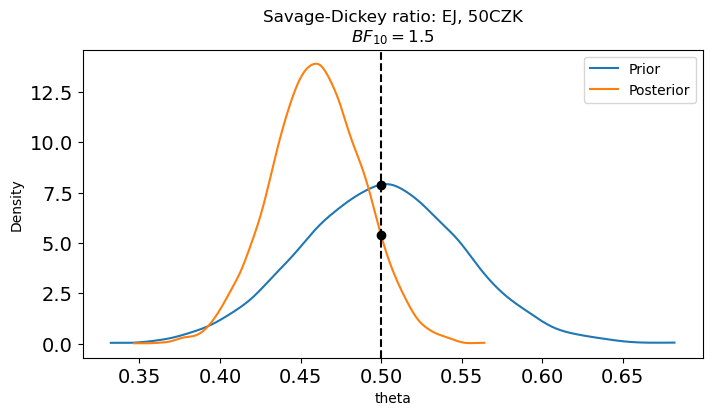

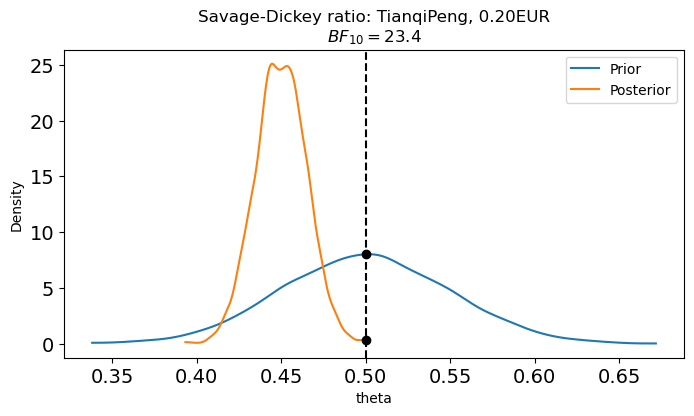

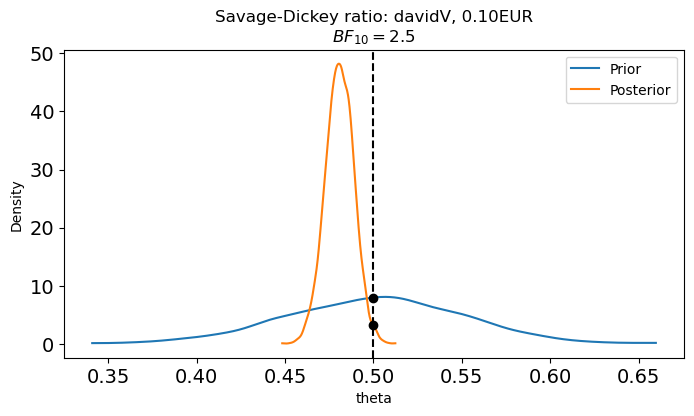

In [202]:
reference_theta = 0.5

savage_dickey_examples = posterior_examples.copy()
for idx, example in savage_dickey_examples.iterrows():
    idata = coin_idatas[example["example_id"]]

    fig, ax = plt.subplots(figsize=(8, 4))
    bf, ax = az.plot_bf(
        idata,
        var_name="theta",
        ref_val=reference_theta,
        ax=ax,
        show=False,
    )
    ax.set_title(
        f"Savage-Dickey ratio: {example['person']}, {example['coin']}\n"
        f"$BF_{{10}}={bf['BF10']:.1f}$"
    )
    savage_dickey_examples.loc[idx, "BF10"] = bf["BF10"]
    savage_dickey_examples.loc[idx, "BF01"] = bf["BF01"]

savage_dickey_table = savage_dickey_examples.rename(
    columns={
        "person": "person",
        "coin": "coin",
        "N": "$N$",
        "theta_hat": r"$\hat{\theta}$",
        "BF10": "$BF_{10}$",
        "BF01": "$BF_{01}$",
    }
)[["person", "coin", "$N$", r"$\hat{\theta}$", "$BF_{10}$", "$BF_{01}$"]]

display(Markdown(markdown_table(savage_dickey_table)))

savage_dickey_bf_10 = savage_dickey_examples.loc[
    savage_dickey_examples["example_id"] == focal_example["example_id"], "BF10"
].item()
savage_dickey_bf_01 = savage_dickey_examples.loc[
    savage_dickey_examples["example_id"] == focal_example["example_id"], "BF01"
].item()


Savage-Dickey is a density ratio, so it depends on the prior density at the reference value. The data are the same in all three panels below: `TianqiPeng / 0.20EUR`. Only the prior changes.


Repeat the Savage-Dickey calculation under several priors.


Fit the focal example under several priors.


In [ ]:
prior_sensitivity_specs = [
    {"prior": r"$\mathrm{Beta}(1,1)$", "alpha": 1.0, "beta": 1.0},
    {"prior": r"$\mathrm{Beta}(0.5,0.5)$", "alpha": 0.2, "beta": 0.2},
    {"prior": rf"current $\mathrm{{Beta}}({prior_alpha:.1f},{prior_beta:.1f})$", "alpha": prior_alpha, "beta": prior_beta},
]


def sample_tianqi_model_with_prior(alpha, beta, random_seed):
    with pm.Model() as model:
        theta = pm.Beta("theta", alpha=alpha, beta=beta)
        pm.Binomial(
            "heads_observed",
            n=n_tosses,
            p=theta,
            observed=heads,
        )
        idata = pm.sample(
            draws=COIN_MODEL_DRAWS,
            tune=COIN_MODEL_TUNE,
            chains=COIN_MODEL_CHAINS,
            cores=COIN_MODEL_CORES,
            random_seed=random_seed,
            target_accept=0.95,
            progressbar=False,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": False},
        )
        prior_idata = pm.sample_prior_predictive(
            draws=COIN_PRIOR_DRAWS,
            var_names=["theta"],
            random_seed=random_seed + 10_000,
            return_inferencedata=True,
        )
    idata.extend(prior_idata)
    return idata


prior_sensitivity_rows = []
prior_sensitivity_idatas = {}
for idx, spec in enumerate(prior_sensitivity_specs):
    idata = sample_tianqi_model_with_prior(spec["alpha"], spec["beta"], random_seed=617_000 + idx)
    prior_sensitivity_idatas[spec["prior"]] = idata

    prior_samples = idata.prior["theta"].values.ravel()
    posterior_samples = idata.posterior["theta"].values.ravel()
    prior_density_at_reference = stats.gaussian_kde(prior_samples)(reference_theta).item()
    posterior_density_at_reference = stats.gaussian_kde(posterior_samples)(reference_theta).item()

    prior_sensitivity_rows.append(
        {
            "prior": spec["prior"],
            r"$p(\theta_0)$": prior_density_at_reference,
            r"$p(\theta_0\mid y)$": posterior_density_at_reference,
            r"$BF_{10}$": prior_density_at_reference / posterior_density_at_reference,
            r"$BF_{01}$": posterior_density_at_reference / prior_density_at_reference,
        }
    )


Plot the Bayes factor view for each prior.


In [ ]:
for spec in prior_sensitivity_specs:
    idata = prior_sensitivity_idatas[spec["prior"]]
    fig, ax = plt.subplots(figsize=(8, 4))
    bf, ax = az.plot_bf(
        idata,
        var_name="theta",
        ref_val=reference_theta,
        ax=ax,
        show=False,
    )
    ax.set_xlim(0, 1)
    ax.set_title(f"{spec['prior']} prior, same data\n$BF_{{10}}={bf['BF10']:.1f}$")


Display the prior-sensitivity table.


In [ ]:
prior_sensitivity_table = pd.DataFrame(prior_sensitivity_rows)
display(Markdown(markdown_table(prior_sensitivity_table)))


<a id="section-64"></a>
## 6.4 ROPE and HDI test

A ROPE replaces the unrealistic point-null question with a practical-equivalence region. The HDI/ROPE comparison turns posterior uncertainty into a hypothesis-test decision.


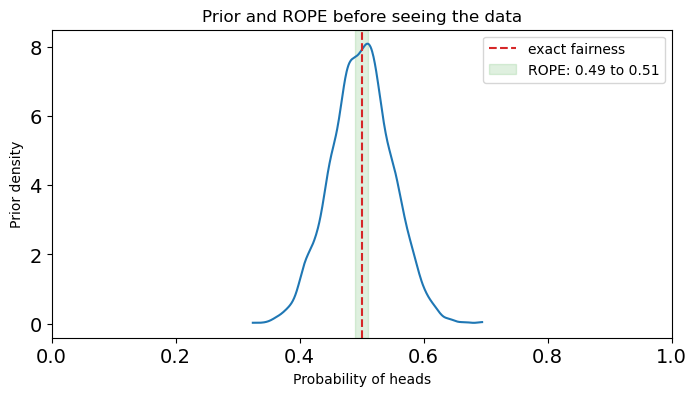

In [204]:
prior = stats.beta(prior_alpha, prior_beta)

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_dist(prior.rvs(size=COIN_PRIOR_DRAWS, random_state=367_143), kind="kde", ax=ax, show=False)
ax.axvline(0.5, color="tab:red", linestyle="--", label="exact fairness")
ax.axvspan(*rope, color="tab:green", alpha=0.15, label="ROPE: 0.49 to 0.51")
ax.set_xlim(0, 1)
ax.set_xlabel("Probability of heads")
ax.set_ylabel("Prior density")
ax.set_title("Prior and ROPE before seeing the data")
ax.legend()


| person | coin | $P(\theta < \mathrm{ROPE})$ | $P(\theta \in \mathrm{ROPE})$ |
| --- | --- | --- | --- |
| EJ | 50CZK | 0.85 | 0.11 |
| TianqiPeng | 0.20EUR | 1.00 | 0.00 |
| davidV | 0.10EUR | 0.88 | 0.12 |

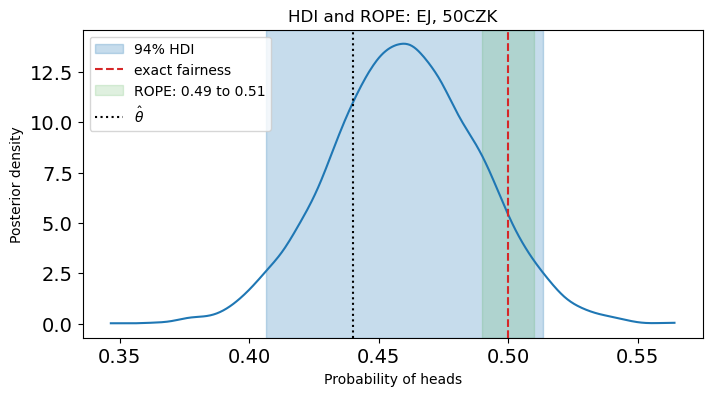

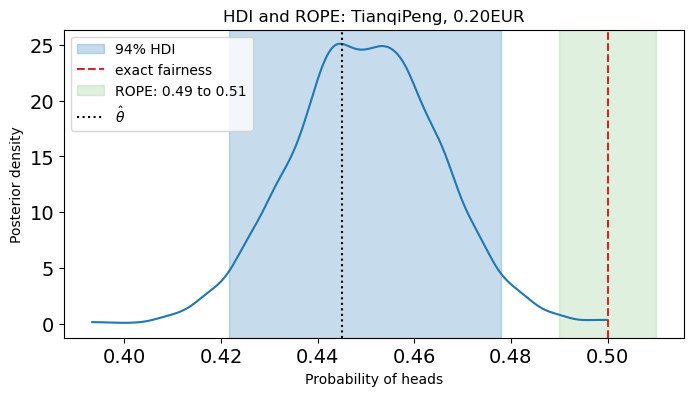

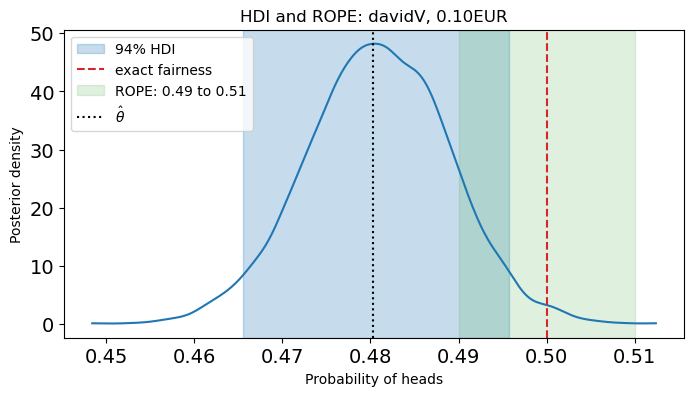

In [205]:
rope_rows = []
for _, example in posterior_examples.iterrows():
    idata = coin_idatas[example["example_id"]]
    theta_samples = idata.posterior["theta"].values.ravel()
    example_interval = az.hdi(theta_samples, hdi_prob=HDI_MASS)

    fig, ax = plt.subplots(figsize=(8, 4))
    az.plot_dist(theta_samples, kind="kde", ax=ax, show=False)
    ax.axvspan(example_interval[0], example_interval[1], color="tab:blue", alpha=0.25, label=f"{HDI_MASS:.0%} HDI")
    ax.axvline(0.5, color="tab:red", linestyle="--", label="exact fairness")
    ax.axvspan(*rope, color="tab:green", alpha=0.15, label="ROPE: 0.49 to 0.51")
    ax.axvline(example["theta_hat"], color="black", linestyle=":", label=r"$\hat{\theta}$")
    ax.set_xlabel("Probability of heads")
    ax.set_ylabel("Posterior density")
    ax.set_title(f"HDI and ROPE: {example['person']}, {example['coin']}")
    ax.legend()

    rope_rows.append(
        {
            "person": example["person"],
            "coin": example["coin"],
            r"$P(\theta < \mathrm{ROPE})$": np.mean(theta_samples < rope[0]),
            r"$P(\theta \in \mathrm{ROPE})$": np.mean((theta_samples >= rope[0]) & (theta_samples <= rope[1])),
        }
    )

rope_summary = pd.DataFrame(rope_rows)
display(Markdown(markdown_table(rope_summary)))


Pooling every toss in the dataset asks a different question: is the overall probability of heads meaningfully different from exact fairness? With this much data, the posterior is very narrow, so the ROPE gives us a direct equivalence-style check.


Pool all tosses to ask whether the whole dataset is practically fair.


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
Sampling: [theta]


| $N$ | $\hat{\theta}$ | 94% HDI | $P(\theta \in \mathrm{ROPE})$ | $P(\theta > \mathrm{ROPE})$ |
| --- | --- | --- | --- | --- |
| 350757 | 0.5001 | [0.4985, 0.5017] | 1.0000 | 0.0000 |

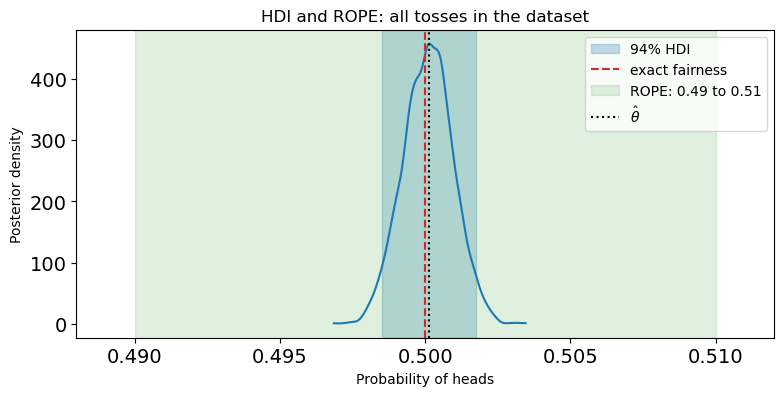

In [206]:
whole_dataset_row = pd.Series(
    {
        "person": "all participants",
        "coin": "all coins",
        "N": int(coin_flips["N"].sum()),
        "heads_total": int(coin_flips["heads_total"].sum()),
    }
)
whole_dataset_row["tails_total"] = whole_dataset_row["N"] - whole_dataset_row["heads_total"]
whole_dataset_row["theta_hat"] = whole_dataset_row["heads_total"] / whole_dataset_row["N"]

whole_dataset_model, whole_dataset_idata = sample_coin_model(
    whole_dataset_row,
    random_seed=367_143 + 100,
)
whole_theta_samples = whole_dataset_idata.posterior["theta"].values.ravel()
whole_hdi = az.hdi(whole_theta_samples, hdi_prob=HDI_MASS)

fig, ax = plt.subplots(figsize=(9, 4))
az.plot_dist(whole_theta_samples, kind="kde", ax=ax, show=False)
ax.axvspan(whole_hdi[0], whole_hdi[1], color="tab:blue", alpha=0.25, label=f"{HDI_MASS:.0%} HDI")
ax.axvline(0.5, color="tab:red", linestyle="--", label="exact fairness")
ax.axvspan(*rope, color="tab:green", alpha=0.15, label="ROPE: 0.49 to 0.51")
ax.axvline(whole_dataset_row["theta_hat"], color="black", linestyle=":", label=r"$\hat{\theta}$")
whole_plot_xlim = (0.488, 0.512)
whole_plot_xticks = np.array([0.49, 0.495, 0.5, 0.505, 0.51])
ax.set_xlim(*whole_plot_xlim)
ax.set_xticks(whole_plot_xticks, [f"{tick:.3f}" for tick in whole_plot_xticks])
ax.set_xlabel("Probability of heads")
ax.set_ylabel("Posterior density")
ax.set_title("HDI and ROPE: all tosses in the dataset")
ax.legend()

outside_direction = ">" if whole_dataset_row["theta_hat"] >= 0.5 else "<"
outside_cutoff = rope[1] if outside_direction == ">" else rope[0]
outside_probability = (
    np.mean(whole_theta_samples > outside_cutoff)
    if outside_direction == ">"
    else np.mean(whole_theta_samples < outside_cutoff)
)
outside_column = rf"$P(\theta {outside_direction} \mathrm{{ROPE}})$"

whole_dataset_rope_table = pd.DataFrame(
    [
        {
            r"$N$": whole_dataset_row["N"],
            r"$\hat{\theta}$": whole_dataset_row["theta_hat"],
            f"{HDI_MASS:.0%} HDI": f"[{whole_hdi[0]:.4f}, {whole_hdi[1]:.4f}]",
            r"$P(\theta \in \mathrm{ROPE})$": np.mean(
                (whole_theta_samples >= rope[0]) & (whole_theta_samples <= rope[1])
            ),
            outside_column: outside_probability,
        }
    ]
)

display(Markdown(markdown_table(whole_dataset_rope_table, float_digits=4)))


<a id="section-65"></a>
## 6.5 Significance

Significance thresholds define how much tail probability we are willing to treat as surprising under a null model.


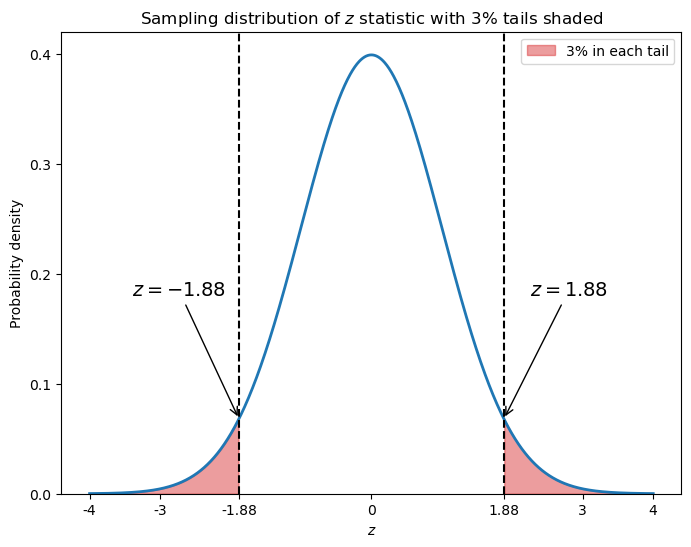

In [212]:
normal_tail_probability = 0.03
normal_z_cutoff = stats.norm.ppf(1 - normal_tail_probability)

x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x)
left_tail = x <= -normal_z_cutoff
right_tail = x >= normal_z_cutoff

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, pdf, color="tab:blue", linewidth=2)
ax.fill_between(
    x[left_tail],
    pdf[left_tail],
    color="tab:red",
    alpha=0.45,
    label="3% in each tail",
)
ax.fill_between(
    x[right_tail],
    pdf[right_tail],
    color="tab:red",
    alpha=0.45,
)
ax.axvline(-normal_z_cutoff, color="black", linestyle="--", linewidth=1.5)
ax.axvline(normal_z_cutoff, color="black", linestyle="--", linewidth=1.5)
ax.annotate(
    rf"$z = -{normal_z_cutoff:.2f}$",
    xy=(-normal_z_cutoff, stats.norm.pdf(normal_z_cutoff)),
    xytext=(-3.4, 0.18),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=14,
)
ax.annotate(
    rf"$z = {normal_z_cutoff:.2f}$",
    xy=(normal_z_cutoff, stats.norm.pdf(normal_z_cutoff)),
    xytext=(2.25, 0.18),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=14,
)

ax.set_title("Sampling distribution of $z$ statistic with 3% tails shaded")
ax.set_xlabel(r"$z$")
ax.set_ylabel("Probability density")
ax.set_xticks([-4, -3, -normal_z_cutoff, 0, normal_z_cutoff, 3, 4])
ax.set_xticklabels(["-4", "-3", f"-{normal_z_cutoff:.2f}", "0", f"{normal_z_cutoff:.2f}", "3", "4"])
ax.set_yticks(np.arange(0, 0.41, 0.10))
ax.set_ylim(0, 0.42)
ax.legend()
plt.show()


<a id="section-66"></a>
## 6.6 Basics of statistical reporting

The notebook reports the data, the estimate, an interval, an effect size, and a hypothesis-test result.


<a id="section-67"></a>
## 6.7 Power

Power is the probability that a hypothesis test detects a true effect under repeated data collection.


<a id="section-68"></a>
## 6.8 Pre-hoc and post-hoc power

Pre-hoc power varies sample size for a chosen effect. Post-hoc power fixes sample size and varies effect size.


### Bayesian power analysis with the EJ preliminary dataset

For pre-hoc planning, we choose a small true effect, $h=0.10$ in the EJ direction, and ask how often the HDI clears the ROPE as the planned sample size increases. Each planned $N$ gets 100 simulated datasets, and the whole grid is fit with one vectorized PyMC model.


Simulate the Bayesian pre-hoc datasets and fit one vectorized PyMC model.


Set the Bayesian pre-hoc power constants and planned effect.


In [ ]:
POWER_NUM_REPS = 100
POWER_SIMULATIONS = POWER_NUM_REPS
POWER_DRAWS = 500
POWER_TUNE = 500
POWER_CHAINS = 2
POWER_TARGET = 0.90
HDI_MASS = 0.94
REFERENCE_THETA = 0.5
POWER_SEED = 367_143

preliminary_person = "EJ"
preliminary_coin = "50CZK"
preliminary_dataset = coin_flips.loc[
    (coin_flips["person"] == preliminary_person) & (coin_flips["coin"] == preliminary_coin)
].squeeze()


def theta_to_cohens_h(theta, reference_theta=REFERENCE_THETA):
    return 2 * np.arcsin(np.sqrt(theta)) - 2 * np.arcsin(np.sqrt(reference_theta))


def theta_from_cohens_h(h, reference_theta=REFERENCE_THETA):
    reference_angle = 2 * np.arcsin(np.sqrt(reference_theta))
    return np.sin((h + reference_angle) / 2) ** 2


preliminary_theta_hat = preliminary_dataset["heads_total"] / preliminary_dataset["N"]
preliminary_h = theta_to_cohens_h(preliminary_theta_hat)
preliminary_direction = -1 if preliminary_h < 0 else 1

PRE_HOC_TRUE_H_MAGNITUDE = 0.10
pre_hoc_true_h = preliminary_direction * PRE_HOC_TRUE_H_MAGNITUDE
pre_hoc_true_theta = theta_from_cohens_h(pre_hoc_true_h)
PRE_HOC_SAMPLE_SIZES = np.array(
    [500, 600, 750, 900, 1100, 1300, 1600, 1900, 2300, 2800, 3400, 4000]
)


Simulate all planned Bayesian pre-hoc datasets.


In [ ]:
pre_hoc_sample_size_group = np.repeat(PRE_HOC_SAMPLE_SIZES, POWER_NUM_REPS)
pre_hoc_rng = np.random.default_rng(POWER_SEED)
pre_hoc_heads = pre_hoc_rng.binomial(
    n=pre_hoc_sample_size_group,
    p=pre_hoc_true_theta,
)


Fit one PyMC model to all planned sample sizes.


In [ ]:
pre_hoc_coords = {"simulation": np.arange(pre_hoc_heads.size)}
with pm.Model(coords=pre_hoc_coords) as pre_hoc_model:
    theta = pm.Beta("theta", alpha=prior_alpha, beta=prior_beta, dims="simulation")
    pm.Binomial(
        "heads",
        n=pre_hoc_sample_size_group,
        p=theta,
        observed=pre_hoc_heads,
        dims="simulation",
    )
    pre_hoc_idata = pm.sample(
        draws=POWER_DRAWS,
        tune=POWER_TUNE,
        chains=POWER_CHAINS,
        cores=1,
        random_seed=POWER_SEED,
        target_accept=0.90,
        progressbar=False,
        compute_convergence_checks=False,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": False},
    )


Show the Bayesian pre-hoc power setup.


In [ ]:
preliminary_power_summary = pd.DataFrame(
    [
        {
            "person": preliminary_person,
            "coin": preliminary_coin,
            r"$N$ in preliminary data": preliminary_dataset["N"],
            "heads": preliminary_dataset["heads_total"],
            "tails": preliminary_dataset["tails_total"],
            r"$\hat{	heta}$": preliminary_theta_hat,
            r"$h$ in preliminary data": preliminary_h,
            r"planned $h_{true}$": pre_hoc_true_h,
            r"planned $	heta_{true}$": pre_hoc_true_theta,
            "simulations per N": POWER_NUM_REPS,
            "PyMC draws per chain": POWER_DRAWS,
            "PyMC tune steps": POWER_TUNE,
            "PyMC chains": POWER_CHAINS,
        }
    ]
)

display(Markdown(markdown_table(preliminary_power_summary, float_digits=3)))


Summarize Bayesian pre-hoc power across planned sample sizes.


In [ ]:
pre_hoc_hdi = az.hdi(pre_hoc_idata.posterior["theta"], hdi_prob=HDI_MASS)["theta"].values
pre_hoc_hdi_low = pre_hoc_hdi[:, 0]
pre_hoc_hdi_high = pre_hoc_hdi[:, 1]
pre_hoc_hdi_overlaps_rope = (pre_hoc_hdi_low <= rope[1]) & (pre_hoc_hdi_high >= rope[0])
pre_hoc_detected = pre_hoc_hdi_high < rope[0]
if pre_hoc_true_theta > REFERENCE_THETA:
    pre_hoc_detected = pre_hoc_hdi_low > rope[1]
pre_hoc_hdi_width = pre_hoc_hdi_high - pre_hoc_hdi_low

pre_hoc_rows = []
for sample_size in PRE_HOC_SAMPLE_SIZES:
    matching = pre_hoc_sample_size_group == sample_size
    pre_hoc_rows.append(
        {
            r"$N$": sample_size,
            "power: HDI clears ROPE": pre_hoc_detected[matching].mean(),
            "HDI overlaps ROPE": pre_hoc_hdi_overlaps_rope[matching].mean(),
            f"median {HDI_MASS:.0%} HDI width": np.median(pre_hoc_hdi_width[matching]),
            "10% HDI width": np.quantile(pre_hoc_hdi_width[matching], 0.10),
            "90% HDI width": np.quantile(pre_hoc_hdi_width[matching], 0.90),
        }
    )

pre_hoc_power = pd.DataFrame(pre_hoc_rows)
pre_hoc_target_candidates = pre_hoc_power.loc[
    pre_hoc_power["power: HDI clears ROPE"] >= POWER_TARGET, r"$N$"
]
pre_hoc_first_n_on_grid = (
    pre_hoc_target_candidates.min() if len(pre_hoc_target_candidates) else np.nan
)

pre_hoc_summary = pd.DataFrame(
    [
        {
            "analysis": "pre hoc PyMC grid",
            r"$h_{true}$": pre_hoc_true_h,
            r"$\theta_{true}$": pre_hoc_true_theta,
            "target power": POWER_TARGET,
            r"first $N$ on grid at target": pre_hoc_first_n_on_grid,
        }
    ]
)

display(Markdown(markdown_table(pre_hoc_summary, float_digits=3)))
display(Markdown(markdown_table(pre_hoc_power, float_digits=3)))


Plot Bayesian pre-hoc power and posterior interval width.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    pre_hoc_power[r"$N$"],
    100 * pre_hoc_power["power: HDI clears ROPE"],
    marker="o",
    label="HDI clears ROPE",
)
ax.plot(
    pre_hoc_power[r"$N$"],
    100 * pre_hoc_power["HDI overlaps ROPE"],
    marker="o",
    label="HDI overlaps ROPE",
)
ax.axhline(100 * POWER_TARGET, color="tab:red", linestyle="--", label="90% target")
if np.isfinite(pre_hoc_first_n_on_grid):
    ax.axvline(
        pre_hoc_first_n_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid $N={pre_hoc_first_n_on_grid:.0f}$",
    )
ax.set_ylim(0, 102)
ax.set_xlabel("planned number of tosses")
ax.set_ylabel("Percentage of datasets")
ax.set_title(rf"Pre-hoc PyMC grid for $h_{{true}}={pre_hoc_true_h:.2f}$")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    pre_hoc_power[r"$N$"],
    pre_hoc_power[f"median {HDI_MASS:.0%} HDI width"],
    marker="o",
)
ax.fill_between(
    pre_hoc_power[r"$N$"],
    pre_hoc_power["10% HDI width"],
    pre_hoc_power["90% HDI width"],
    alpha=0.20,
    label="middle 80% of simulated widths",
)
if np.isfinite(pre_hoc_first_n_on_grid):
    ax.axvline(pre_hoc_first_n_on_grid, color="black", linestyle=":")
ax.set_xlabel("planned number of tosses")
ax.set_ylabel(f"{HDI_MASS:.0%} HDI width")
ax.set_title("Posterior interval width across planned sample sizes")
ax.legend()
plt.show()


### Post-hoc power analysis with fixed sample size

Now fix the sample size at $N=1000$ and vary the true effect size. As in the pre-hoc power analysis, each grid point gets repeated simulated datasets and the whole collection is fit with one vectorized PyMC model.

Set up and fit one vectorized PyMC model for the post-hoc effect-size grid.


In [ ]:
POST_HOC_NUM_REPS = 100
POST_HOC_SAMPLE_SIZE = 1000
POST_HOC_EFFECT_MAGNITUDES = np.round(np.arange(0.08, 0.2, 0.02), 3)
POST_HOC_MASS_IN_ROPE = 0.99
POST_HOC_DRAWS = 1500
POST_HOC_TUNE = 1500
POST_HOC_CHAINS = 2
POST_HOC_SEED = 617_143

post_hoc_true_h_by_effect = -1 * POST_HOC_EFFECT_MAGNITUDES
post_hoc_true_theta_by_effect = theta_from_cohens_h(post_hoc_true_h_by_effect)
post_hoc_effect_magnitudes = POST_HOC_EFFECT_MAGNITUDES
post_hoc_sample_size = POST_HOC_SAMPLE_SIZE

post_hoc_true_theta = np.repeat(post_hoc_true_theta_by_effect, POST_HOC_NUM_REPS)
post_hoc_effect_group = np.repeat(post_hoc_effect_magnitudes, POST_HOC_NUM_REPS)
post_hoc_rng = np.random.default_rng(POST_HOC_SEED)
post_hoc_heads = post_hoc_rng.binomial(
    n=post_hoc_sample_size,
    p=post_hoc_true_theta,
)

post_hoc_coords = {"simulation": np.arange(post_hoc_true_theta.size)}
with pm.Model(coords=post_hoc_coords) as post_hoc_model:
    theta = pm.Beta("theta", alpha=prior_alpha, beta=prior_beta, dims="simulation")
    pm.Binomial(
        "heads",
        n=post_hoc_sample_size,
        p=theta,
        observed=post_hoc_heads,
        dims="simulation",
    )
    post_hoc_idata = pm.sample(
        draws=POST_HOC_DRAWS,
        tune=POST_HOC_TUNE,
        chains=POST_HOC_CHAINS,
        cores=1,
        random_seed=POST_HOC_SEED,
        target_accept=0.90,
        progressbar=False,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": False},
    )

post_hoc_hdi = az.hdi(post_hoc_idata.posterior["theta"], hdi_prob=HDI_MASS)["theta"].values
post_hoc_hdi_low = post_hoc_hdi[:, 0]
post_hoc_hdi_high = post_hoc_hdi[:, 1]
post_hoc_hdi_overlaps_rope = (post_hoc_hdi_low <= rope[1]) & (post_hoc_hdi_high >= rope[0])
post_hoc_detected = post_hoc_hdi_high < rope[0]
post_hoc_hdi_width = post_hoc_hdi_high - post_hoc_hdi_low

post_hoc_rows = []
for effect_magnitude, true_h, true_theta in zip(
    post_hoc_effect_magnitudes,
    post_hoc_true_h_by_effect,
    post_hoc_true_theta_by_effect,
):
    matching = post_hoc_effect_group == effect_magnitude
    post_hoc_rows.append(
        {
            r"$\vert h_{true} \vert$": effect_magnitude,
            r"$h_{true}$": true_h,
            r"$\theta_{true}$": true_theta,
            r"$\theta_{true}-0.5$": true_theta - REFERENCE_THETA,
            "power: HDI clears ROPE": post_hoc_detected[matching].mean(),
            "HDI overlaps ROPE": post_hoc_hdi_overlaps_rope[matching].mean(),
            f"median {HDI_MASS:.0%} HDI width": np.median(post_hoc_hdi_width[matching]),
        }
    )


Summarize post-hoc power at each effect size.


In [ ]:
post_hoc_power = pd.DataFrame(post_hoc_rows)
post_hoc_target_candidates = post_hoc_power.loc[
    post_hoc_power["power: HDI clears ROPE"] >= POWER_TARGET, r"$\vert h_{true} \vert$"
]
post_hoc_first_effect_on_grid = (
    post_hoc_target_candidates.min() if len(post_hoc_target_candidates) else np.nan
)
post_hoc_threshold_row = post_hoc_power.loc[
    post_hoc_power[r"$\vert h_{true} \vert$"] == post_hoc_first_effect_on_grid
]
post_hoc_threshold_theta = (
    post_hoc_threshold_row[r"$\theta_{true}$"].iloc[0]
    if len(post_hoc_threshold_row)
    else np.nan
)
post_hoc_threshold_difference = (
    post_hoc_threshold_row[r"$\theta_{true}-0.5$"].iloc[0]
    if len(post_hoc_threshold_row)
    else np.nan
)

post_hoc_summary = pd.DataFrame(
    [
        {
            "analysis": "post hoc PyMC grid",
            r"$N$ fixed": post_hoc_sample_size,
            "target power": POWER_TARGET,
            r"first $\vert h_{true} \vert$ on grid at target": post_hoc_first_effect_on_grid,
            r"$\theta_{true}$ at target": post_hoc_threshold_theta,
            r"$\theta_{true}-0.5$ at target": post_hoc_threshold_difference,
        }
    ]
)

display(Markdown(markdown_table(post_hoc_summary, float_digits=3)))
display(Markdown(markdown_table(post_hoc_power, float_digits=3)))


Plot post-hoc power as a function of true effect size.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    post_hoc_power[r"$\vert h_{true} \vert$"],
    post_hoc_power["power: HDI clears ROPE"],
    marker="o",
    label="HDI clears ROPE",
)
ax.plot(
    post_hoc_power[r"$\vert h_{true} \vert$"],
    post_hoc_power["HDI overlaps ROPE"],
    marker="o",
    label="HDI overlaps ROPE",
)
ax.axhline(POWER_TARGET, color="tab:red", linestyle="--", label="90% target")
if np.isfinite(post_hoc_first_effect_on_grid):
    ax.axvline(
        post_hoc_first_effect_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid $\vert h \vert={post_hoc_first_effect_on_grid:.3f}$",
    )
ax.set_ylim(0, 1.02)
ax.set_xlabel(r"true effect size $\vert h \vert$, in the EJ direction")
ax.set_ylabel("simulation proportion")
ax.set_title(rf"Post hoc PyMC grid with $N={post_hoc_sample_size}$")
ax.legend()
plt.show()


<a id="section-69"></a>
## 6.9 Frequentist methods

Frequentist tests compare a statistic with its sampling distribution under the null model. For large binomial samples, the z statistic is approximately normal.


In [213]:
frequentist_test_rows = []
for _, example in effect_size_examples.iterrows():
    heads_count = int(example["heads_total"])
    toss_count = int(example["N"])
    theta_hat = heads_count / toss_count
    z_statistic = (theta_hat - 0.5) / np.sqrt(0.5 * 0.5 / toss_count)
    normal_approx_p = 2 * stats.norm.sf(abs(z_statistic))

    frequentist_test_rows.append(
        {
            "person": example["person"],
            "coin": example["coin"],
            "N": toss_count,
            "heads proportion": theta_hat,
            "difference from 0.5": theta_hat - 0.5,
            "z statistic": z_statistic,
            "normal approx p-value": normal_approx_p,
        }
    )

frequentist_coin_tests = pd.DataFrame(frequentist_test_rows)
frequentist_coin_tests.style.format(
    {
        "heads proportion": "{:.3f}",
        "difference from 0.5": "{:.3f}",
        "z statistic": "{:.2f}",
        "exact p-value two-sided": "{:.4g}",
        "exact p-value fewer heads": "{:.4g}",
        "normal approx p-value": "{:.4g}",
    }
)


,person,coin,N,heads proportion,difference from 0.5,z statistic,normal approx p-value
0,EJ,50CZK,200,0.440,-0.060,-1.70,0.08969
1,TianqiPeng,0.20EUR,1000,0.445,-0.055,-3.48,0.0005042
2,davidV,0.10EUR,3660,0.480,-0.020,-2.38,0.0173


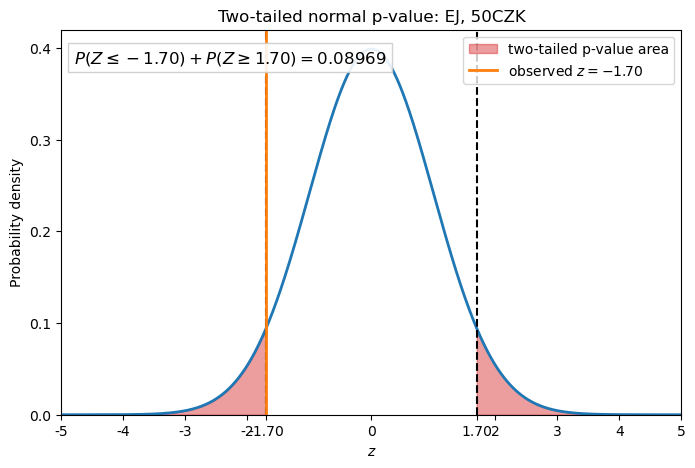

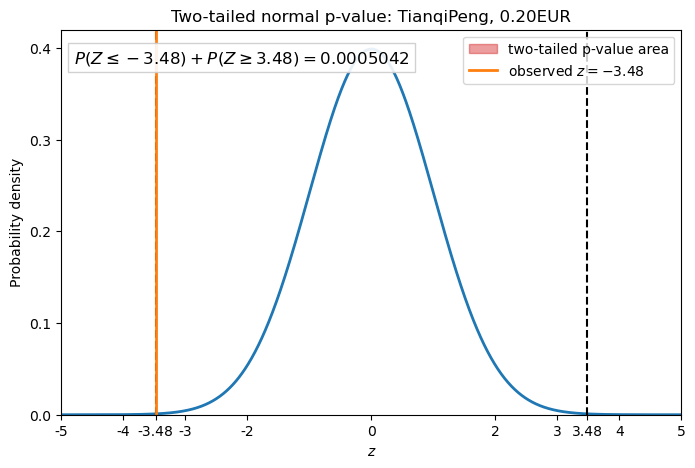

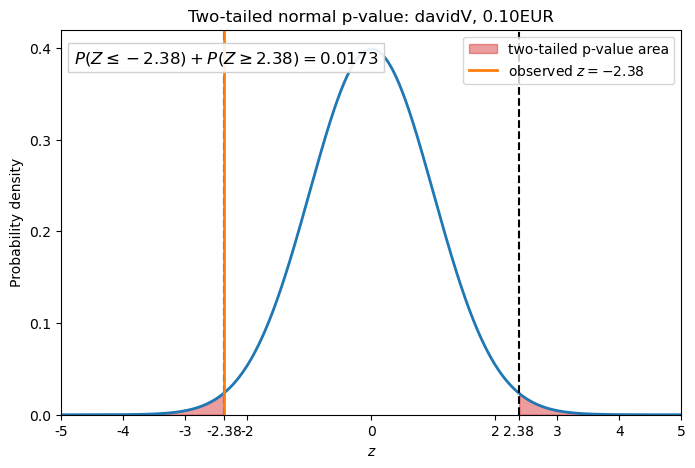

In [214]:
standard_normal_x = np.linspace(-5, 5, 2000)
standard_normal_pdf = stats.norm.pdf(standard_normal_x)

for _, test_row in frequentist_coin_tests.iterrows():
    z_statistic = test_row["z statistic"]
    z_cutoff = abs(z_statistic)
    p_value = 2 * stats.norm.sf(z_cutoff)
    left_tail = standard_normal_x <= -z_cutoff
    right_tail = standard_normal_x >= z_cutoff

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(standard_normal_x, standard_normal_pdf, color="tab:blue", linewidth=2)
    ax.fill_between(
        standard_normal_x[left_tail],
        standard_normal_pdf[left_tail],
        color="tab:red",
        alpha=0.45,
        label="two-tailed p-value area",
    )
    ax.fill_between(
        standard_normal_x[right_tail],
        standard_normal_pdf[right_tail],
        color="tab:red",
        alpha=0.45,
    )
    ax.axvline(-z_cutoff, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(z_cutoff, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(z_statistic, color="tab:orange", linewidth=2, label=rf"observed $z={z_statistic:.2f}$")
    ax.text(
        0.02,
        0.95,
        rf"$P(Z \leq -{z_cutoff:.2f}) + P(Z \geq {z_cutoff:.2f}) = {p_value:.4g}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
    )

    ax.set_title(f"Two-tailed normal p-value: {test_row['person']}, {test_row['coin']}")
    ax.set_xlabel(r"$z$")
    ax.set_ylabel("Probability density")
    xticks = sorted([-5, -4, -3, -2, -z_cutoff, 0, z_cutoff, 2, 3, 4, 5])
    xtick_labels = [
        f"{tick:.2f}" if np.isclose(abs(tick), z_cutoff) else f"{tick:.0f}"
        for tick in xticks
    ]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(np.arange(0, 0.41, 0.10))
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 0.42)
    ax.legend(loc="upper right")
    plt.show()


### Frequentist power analysis with the normal approximation

We can run the same pre-hoc and post-hoc power questions with the frequentist z test. Here the simulated datasets are still binomial coin-toss datasets, but the decision rule is the two-tailed normal approximation: reject exact fairness when the simulated z statistic falls outside the critical values for $lpha=0.06$.


Define the normal-approximation power helper.


In [ ]:
FREQUENTIST_POWER_SEED = 817_143
FREQUENTIST_POWER_TARGET = POWER_TARGET
frequentist_alpha = SIGNIFICANCE_ALPHA
frequentist_z_critical = stats.norm.ppf(1 - frequentist_alpha / 2)
frequentist_rng = np.random.default_rng(FREQUENTIST_POWER_SEED)


def summarize_frequentist_z_power(sample_sizes, true_thetas, group_values):
    simulated_heads = frequentist_rng.binomial(n=sample_sizes, p=true_thetas)
    theta_hat = simulated_heads / sample_sizes
    z_statistics = (theta_hat - REFERENCE_THETA) / np.sqrt(
        REFERENCE_THETA * (1 - REFERENCE_THETA) / sample_sizes
    )
    two_tailed_p_values = 2 * stats.norm.sf(np.abs(z_statistics))
    rejected = np.abs(z_statistics) >= frequentist_z_critical

    rows = []
    for group_value in np.unique(group_values):
        matching = group_values == group_value
        rows.append(
            {
                "grid value": group_value,
                "power: z test rejects": rejected[matching].mean(),
                "median p-value": np.median(two_tailed_p_values[matching]),
                "10% p-value": np.quantile(two_tailed_p_values[matching], 0.10),
                "90% p-value": np.quantile(two_tailed_p_values[matching], 0.90),
                "median z statistic": np.median(z_statistics[matching]),
            }
        )
    return pd.DataFrame(rows)


Estimate frequentist pre-hoc power over planned sample sizes.


Summarize frequentist pre-hoc power across sample sizes.


In [ ]:
frequentist_pre_hoc_sample_sizes = np.repeat(PRE_HOC_SAMPLE_SIZES, POWER_NUM_REPS)
frequentist_pre_hoc_true_thetas = np.full(
    frequentist_pre_hoc_sample_sizes.size,
    pre_hoc_true_theta,
)
frequentist_pre_hoc_power = summarize_frequentist_z_power(
    sample_sizes=frequentist_pre_hoc_sample_sizes,
    true_thetas=frequentist_pre_hoc_true_thetas,
    group_values=frequentist_pre_hoc_sample_sizes,
).rename(columns={"grid value": "N"})
frequentist_pre_hoc_power["N"] = frequentist_pre_hoc_power["N"].astype(int)

frequentist_pre_hoc_target_candidates = frequentist_pre_hoc_power.loc[
    frequentist_pre_hoc_power["power: z test rejects"] >= FREQUENTIST_POWER_TARGET,
    "N",
]
frequentist_pre_hoc_first_n_on_grid = (
    frequentist_pre_hoc_target_candidates.min()
    if len(frequentist_pre_hoc_target_candidates)
    else np.nan
)

frequentist_pre_hoc_summary = pd.DataFrame(
    [
        {
            "analysis": "pre hoc z-test grid",
            r"$h_{true}$": pre_hoc_true_h,
            r"$	heta_{true}$": pre_hoc_true_theta,
            r"$lpha$": frequentist_alpha,
            r"critical $|z|$": frequentist_z_critical,
            "target power": FREQUENTIST_POWER_TARGET,
            "first N on grid at target": frequentist_pre_hoc_first_n_on_grid,
        }
    ]
)

display(
    frequentist_pre_hoc_summary.style.format(
        {
            r"$h_{true}$": "{:.3f}",
            r"$	heta_{true}$": "{:.3f}",
            r"$lpha$": "{:.2f}",
            r"critical $|z|$": "{:.3f}",
            "target power": "{:.2f}",
            "first N on grid at target": "{:.0f}",
        }
    )
)
display(
    frequentist_pre_hoc_power.style.format(
        {
            "power: z test rejects": "{:.3f}",
            "median p-value": "{:.4f}",
            "10% p-value": "{:.4f}",
            "90% p-value": "{:.4f}",
            "median z statistic": "{:.2f}",
        }
    )
)


Plot frequentist pre-hoc power and p-values.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    frequentist_pre_hoc_power["N"],
    100 * frequentist_pre_hoc_power["power: z test rejects"],
    marker="o",
    label="normal z test rejects",
)
ax.axhline(100 * FREQUENTIST_POWER_TARGET, color="tab:red", linestyle="--", label="90% target")
if np.isfinite(frequentist_pre_hoc_first_n_on_grid):
    ax.axvline(
        frequentist_pre_hoc_first_n_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid $N={frequentist_pre_hoc_first_n_on_grid:.0f}$",
    )
ax.set_ylim(0, 102)
ax.set_xlabel("planned number of tosses")
ax.set_ylabel("Percentage of datasets")
ax.set_title(rf"Pre-hoc normal-approximation power for $h_{{true}}={pre_hoc_true_h:.2f}$")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    frequentist_pre_hoc_power["N"],
    frequentist_pre_hoc_power["median p-value"],
    marker="o",
    label="median p-value",
)
ax.fill_between(
    frequentist_pre_hoc_power["N"],
    frequentist_pre_hoc_power["10% p-value"],
    frequentist_pre_hoc_power["90% p-value"],
    alpha=0.20,
    label="middle 80% of simulated p-values",
)
ax.axhline(frequentist_alpha, color="tab:red", linestyle="--", label=rf"$lpha={frequentist_alpha:.2f}$")
if np.isfinite(frequentist_pre_hoc_first_n_on_grid):
    ax.axvline(frequentist_pre_hoc_first_n_on_grid, color="black", linestyle=":")
ax.set_xlabel("planned number of tosses")
ax.set_ylabel("two-tailed p-value")
ax.set_title("Normal-approximation p-values across planned sample sizes")
ax.legend()
plt.show()


Estimate frequentist post-hoc power over true effect sizes.


Summarize frequentist post-hoc power across effect sizes.


In [ ]:
frequentist_post_hoc_effect_group = np.repeat(post_hoc_effect_magnitudes, POST_HOC_NUM_REPS)
frequentist_post_hoc_true_h = -1 * frequentist_post_hoc_effect_group
frequentist_post_hoc_true_theta = theta_from_cohens_h(frequentist_post_hoc_true_h)
frequentist_post_hoc_sample_sizes = np.full(
    frequentist_post_hoc_effect_group.size,
    post_hoc_sample_size,
    dtype=int,
)
frequentist_post_hoc_power = summarize_frequentist_z_power(
    sample_sizes=frequentist_post_hoc_sample_sizes,
    true_thetas=frequentist_post_hoc_true_theta,
    group_values=frequentist_post_hoc_effect_group,
).rename(columns={"grid value": "effect magnitude"})
frequentist_post_hoc_power[r"$h_{true}$"] = -1 * frequentist_post_hoc_power["effect magnitude"]
frequentist_post_hoc_power[r"$	heta_{true}$"] = theta_from_cohens_h(
    frequentist_post_hoc_power[r"$h_{true}$"].to_numpy()
)

frequentist_post_hoc_target_candidates = frequentist_post_hoc_power.loc[
    frequentist_post_hoc_power["power: z test rejects"] >= FREQUENTIST_POWER_TARGET,
    "effect magnitude",
]
frequentist_post_hoc_first_effect_on_grid = (
    frequentist_post_hoc_target_candidates.min()
    if len(frequentist_post_hoc_target_candidates)
    else np.nan
)

frequentist_post_hoc_summary = pd.DataFrame(
    [
        {
            "analysis": "post hoc z-test grid",
            "N fixed": post_hoc_sample_size,
            r"$lpha$": frequentist_alpha,
            r"critical $|z|$": frequentist_z_critical,
            "target power": FREQUENTIST_POWER_TARGET,
            "first effect magnitude on grid at target": frequentist_post_hoc_first_effect_on_grid,
        }
    ]
)


Display the frequentist post-hoc power tables.


In [ ]:
display(
    frequentist_post_hoc_summary.style.format(
        {
            r"$lpha$": "{:.2f}",
            r"critical $|z|$": "{:.3f}",
            "target power": "{:.2f}",
            "first effect magnitude on grid at target": "{:.3f}",
        }
    )
)
display(
    frequentist_post_hoc_power[
        [
            "effect magnitude",
            r"$h_{true}$",
            r"$	heta_{true}$",
            "power: z test rejects",
            "median p-value",
            "median z statistic",
        ]
    ].style.format(
        {
            "effect magnitude": "{:.3f}",
            r"$h_{true}$": "{:.3f}",
            r"$	heta_{true}$": "{:.3f}",
            "power: z test rejects": "{:.3f}",
            "median p-value": "{:.4f}",
            "median z statistic": "{:.2f}",
        }
    )
)


Plot frequentist post-hoc power and p-values.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    frequentist_post_hoc_power["effect magnitude"],
    frequentist_post_hoc_power["power: z test rejects"],
    marker="o",
    label="normal z test rejects",
)
ax.axhline(FREQUENTIST_POWER_TARGET, color="tab:red", linestyle="--", label="90% target")
if np.isfinite(frequentist_post_hoc_first_effect_on_grid):
    ax.axvline(
        frequentist_post_hoc_first_effect_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid $|h|={frequentist_post_hoc_first_effect_on_grid:.3f}$",
    )
ax.set_ylim(0, 1.02)
ax.set_xlabel("true effect size |h|, in the EJ direction")
ax.set_ylabel("simulation proportion")
ax.set_title(rf"Post-hoc normal-approximation power with $N={post_hoc_sample_size}$")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    frequentist_post_hoc_power["effect magnitude"],
    frequentist_post_hoc_power["median p-value"],
    marker="o",
    label="median p-value",
)
ax.axhline(frequentist_alpha, color="tab:red", linestyle="--", label=rf"$lpha={frequentist_alpha:.2f}$")
if np.isfinite(frequentist_post_hoc_first_effect_on_grid):
    ax.axvline(frequentist_post_hoc_first_effect_on_grid, color="black", linestyle=":")
ax.set_xlabel("true effect size |h|, in the EJ direction")
ax.set_ylabel("two-tailed p-value")
ax.set_title("Normal-approximation p-values across true effect sizes")
ax.legend()
plt.show()


<a id="section-610"></a>
## 6.10 Comparing two groups

The hospital example extends the one-proportion question to a two-group comparison: the population mean death rate for PCI hospitals versus Non-PCI hospitals.


In [216]:
HOSPITAL_COLOR = "#4c78a8"
HIERARCHICAL_COLOR = "#b279a2"
PCI_COLOR = "#54a24b"
NONPCI_COLOR = "#e45756"
INTERVAL_COLOR = "#8a8a8a"

hospital_death_data = read_required_csv(
    "DeathHeartAttackDataNYCfull.txt",
    sep=r"\s+",
)

hospital_death_data = hospital_death_data.assign(
    Hospital=lambda df: df["Hospital"].str.replace("_", " ", regex=False),
    Borough=lambda df: df["Borough"].str.replace("_", " ", regex=False),
    Type=lambda df: df["Type"].map({"P": "PCI", "N": "Non-PCI"}),
)
hospital_death_data["DeathRate"] = hospital_death_data["Deaths"] / hospital_death_data["Cases"]
hospital_death_data["HospitalShort"] = hospital_death_data["Hospital"].str.replace(
    " Hospital",
    "",
    regex=False,
)

hospital_type_order = ["Non-PCI", "PCI"]
hospital_death_data["Type"] = pd.Categorical(
    hospital_death_data["Type"],
    categories=hospital_type_order,
    ordered=True,
)
hospital_death_data = hospital_death_data.sort_values(["Type", "DeathRate"]).reset_index(drop=True)

hospital_names = hospital_death_data["HospitalShort"].to_numpy()
hospital_type_idx = hospital_death_data["Type"].cat.codes.to_numpy()
hospital_cases = hospital_death_data["Cases"].to_numpy()
hospital_deaths = hospital_death_data["Deaths"].to_numpy()
hospital_observed_rate = hospital_deaths / hospital_cases

hospital_type_summary = (
    hospital_death_data.groupby("Type", observed=False)
    .agg(
        hospitals=("Hospital", "count"),
        cases=("Cases", "sum"),
        deaths=("Deaths", "sum"),
        mean_hospital_death_rate=("DeathRate", "mean"),
    )
    .assign(pooled_death_rate=lambda df: df["deaths"] / df["cases"])
    .reset_index()
)

hospital_type_summary.style.format(
    {
        "mean_hospital_death_rate": "{:.3f}",
        "pooled_death_rate": "{:.3f}",
    }
)


,Type,hospitals,cases,deaths,mean_hospital_death_rate,pooled_death_rate
0,Non-PCI,22,2411,197,0.080,0.082
1,PCI,23,6824,501,0.073,0.073


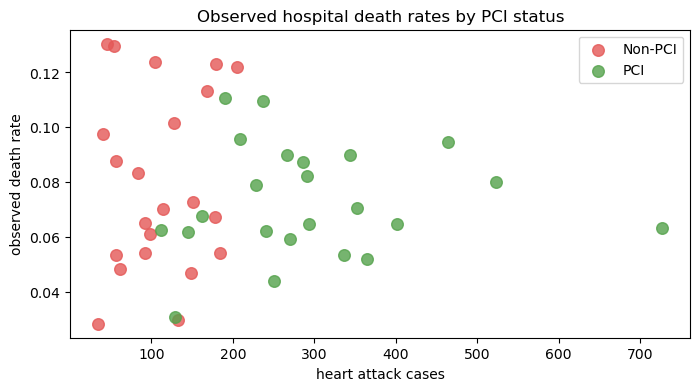

In [217]:
fig, ax = plt.subplots(figsize=(8, 4))
for hospital_type, color in [("Non-PCI", NONPCI_COLOR), ("PCI", PCI_COLOR)]:
    rows = hospital_death_data["Type"] == hospital_type
    ax.scatter(
        hospital_death_data.loc[rows, "Cases"],
        hospital_death_data.loc[rows, "DeathRate"],
        s=70,
        alpha=0.8,
        color=color,
        label=hospital_type,
    )
ax.set_xlabel("heart attack cases")
ax.set_ylabel("observed death rate")
ax.set_title("Observed hospital death rates by PCI status")
ax.legend()
plt.show()


### Hierarchical PCI versus Non-PCI model

Each hospital gets its own death probability, but hospitals partially pool toward the population mean for their hospital type.

$$
\theta_i \sim \mathrm{Beta}(\mu_{type[i]}, \nu_{type[i]})
$$

$$
z_i \sim \mathrm{Binomial}(Cases_i, \theta_i)
$$

The sampled effect of interest is:

$$
\Delta_\mu = \mu_{PCI} - \mu_{Non\text{-}PCI}
$$


In [218]:
hospital_prior = pz.maxent(
    pz.Beta(),
    lower=0.01,
    upper=0.30,
    mass=0.95,
    plot=False,
)
hospital_omega_alpha = float(hospital_prior.alpha)
hospital_omega_beta = float(hospital_prior.beta)
hospital_mu_mu_theta = hospital_omega_alpha / (hospital_omega_alpha + hospital_omega_beta)
hospital_nu_mu_theta = hospital_omega_alpha + hospital_omega_beta

hospital_sigma_theta = 0.05
hospital_implied_theta_prior = pz.Beta(mu=hospital_mu_mu_theta, sigma=hospital_sigma_theta)
hospital_sigma_nu_theta = float(hospital_implied_theta_prior.nu)

HOSPITAL_MODEL_DRAWS = 1000
HOSPITAL_MODEL_TUNE = 1000
HOSPITAL_MODEL_CHAINS = 4
HOSPITAL_MODEL_SEED = 367_143

hospital_prior_summary = pd.DataFrame(
    [
        {"parameter": "omega alpha", "value": hospital_omega_alpha},
        {"parameter": "omega beta", "value": hospital_omega_beta},
        {"parameter": "mu prior mean", "value": hospital_mu_mu_theta},
        {"parameter": "mu prior concentration", "value": hospital_nu_mu_theta},
        {"parameter": "nu HalfNormal sigma", "value": hospital_sigma_nu_theta},
    ]
)

hospital_prior_summary.style.format({"value": "{:.3f}"})


,parameter,value
0,omega alpha,2.442
1,omega beta,14.807
2,mu prior mean,0.142
3,mu prior concentration,17.248
4,nu HalfNormal sigma,47.606


Fit the hierarchical PCI versus Non-PCI hospital model.


In [219]:
hospital_coords = {
    "hospital": hospital_names,
    "hospital_type": hospital_type_order,
}

with pm.Model(coords=hospital_coords) as hospital_type_model:
    mu_type = pm.Beta(
        "mu_type",
        mu=hospital_mu_mu_theta,
        nu=hospital_nu_mu_theta,
        dims="hospital_type",
    )
    nu_type = pm.HalfNormal(
        "nu_type",
        sigma=hospital_sigma_nu_theta,
        dims="hospital_type",
    )

    theta = pm.Beta(
        "theta",
        mu=mu_type[hospital_type_idx],
        nu=nu_type[hospital_type_idx],
        dims="hospital",
    )
    pm.Binomial(
        "deaths",
        n=hospital_cases,
        p=theta,
        observed=hospital_deaths,
        dims="hospital",
    )

    mu_nonpci = pm.Deterministic("mu_nonpci", mu_type[0])
    mu_pci = pm.Deterministic("mu_pci", mu_type[1])
    mu_difference = pm.Deterministic("mu_difference", mu_pci - mu_nonpci)
    risk_ratio = pm.Deterministic("risk_ratio", mu_pci / mu_nonpci)
    odds_ratio = pm.Deterministic(
        "odds_ratio",
        (mu_pci / (1 - mu_pci)) / (mu_nonpci / (1 - mu_nonpci)),
    )
    log_odds_ratio = pm.Deterministic("log_odds_ratio", pm.math.log(odds_ratio))
    cohens_h = pm.Deterministic(
        "cohens_h",
        2 * pm.math.arcsin(pm.math.sqrt(mu_pci))
        - 2 * pm.math.arcsin(pm.math.sqrt(mu_nonpci)),
    )

    idata_hospital_type = pm.sample(
        draws=HOSPITAL_MODEL_DRAWS,
        tune=HOSPITAL_MODEL_TUNE,
        chains=HOSPITAL_MODEL_CHAINS,
        target_accept=0.90,
        random_seed=HOSPITAL_MODEL_SEED,
        progressbar=False,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": False},
    )

az.summary(
    idata_hospital_type,
    var_names=["mu_nonpci", "mu_pci", "mu_difference", "risk_ratio", "odds_ratio", "cohens_h"],
    hdi_prob=HDI_MASS,
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_type, nu_type, theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_nonpci,0.084,0.009,0.067,0.102,0.000,0.000,4012.0,3026.0,1.0
mu_pci,0.076,0.006,0.065,0.088,0.000,0.000,5166.0,3238.0,1.0
mu_difference,-0.008,0.011,-0.028,0.013,0.000,0.000,4198.0,2989.0,1.0
risk_ratio,0.920,0.125,0.695,1.152,0.002,0.002,4257.0,2801.0,1.0
odds_ratio,0.914,0.136,0.674,1.167,0.002,0.002,4252.0,2702.0,1.0
cohens_h,-0.028,0.040,-0.101,0.048,0.001,0.001,4227.0,2875.0,1.0


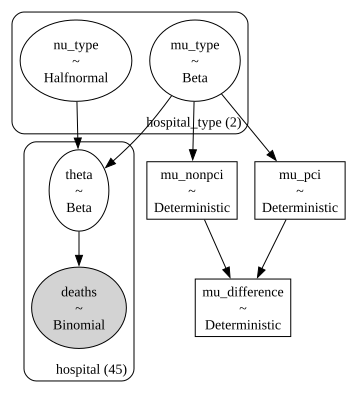

In [226]:
pm.model_to_graphviz(hospital_type_model, 
                     var_names=[
                         "mu_type", 
                         "nu_type", 
                         "theta", 
                         "deaths", 
                         "mu_nonpci", 
                         "mu_pci", 
                         "mu_difference"])

### Effect sizes for the difference in death rates

For two proportions, the same effect-size families are available: the raw difference in rates, risk ratio, odds ratio, log odds ratio, and Cohen's $h$. Here every quantity is computed from posterior samples of the two population means.


In [220]:
def summarize_posterior_samples(samples, label):
    samples = np.asarray(samples)
    interval = az.hdi(samples, hdi_prob=HDI_MASS)
    return {
        "effect size": label,
        "posterior mean": samples.mean(),
        f"{HDI_MASS:.0%} HDI low": interval[0],
        f"{HDI_MASS:.0%} HDI high": interval[1],
        "posterior median": np.median(samples),
    }

hospital_effect_samples = az.extract(
    idata_hospital_type,
    var_names=[
        "mu_nonpci",
        "mu_pci",
        "mu_difference",
        "risk_ratio",
        "odds_ratio",
        "log_odds_ratio",
        "cohens_h",
    ],
    combined=True,
)

hospital_effect_size_table = pd.DataFrame(
    [
        summarize_posterior_samples(hospital_effect_samples["mu_nonpci"], "Non-PCI population mean death rate"),
        summarize_posterior_samples(hospital_effect_samples["mu_pci"], "PCI population mean death rate"),
        summarize_posterior_samples(hospital_effect_samples["mu_difference"], "difference: PCI minus Non-PCI"),
        summarize_posterior_samples(hospital_effect_samples["risk_ratio"], "risk ratio: PCI / Non-PCI"),
        summarize_posterior_samples(hospital_effect_samples["odds_ratio"], "odds ratio"),
        summarize_posterior_samples(hospital_effect_samples["log_odds_ratio"], "log odds ratio"),
        summarize_posterior_samples(hospital_effect_samples["cohens_h"], "Cohen h"),
    ]
)

hospital_effect_size_table.style.format(
    {
        "posterior mean": "{:.4f}",
        f"{HDI_MASS:.0%} HDI low": "{:.4f}",
        f"{HDI_MASS:.0%} HDI high": "{:.4f}",
        "posterior median": "{:.4f}",
    }
)


,effect size,posterior mean,94% HDI low,94% HDI high,posterior median
0,Non-PCI population mean death rate,0.0840,0.0674,0.1016,0.0836
1,PCI population mean death rate,0.0763,0.0647,0.0884,0.0761
2,difference: PCI minus Non-PCI,-0.0076,-0.0277,0.0132,-0.0074
3,risk ratio: PCI / Non-PCI,0.9199,0.6950,1.1520,0.9123
4,odds ratio,0.9138,0.6741,1.1666,0.9050
5,log odds ratio,-0.1010,-0.3671,0.1777,-0.0998
6,Cohen h,-0.0277,-0.1009,0.0481,-0.0271


### ROPE / HDI check for the population-rate difference

A ROPE of +/- 0.005 says that PCI and Non-PCI population mean death rates are practically equivalent if they differ by less than half a percentage point.


Compare the posterior difference with the ROPE.


,parameter,posterior mean,94% HDI low,94% HDI high,ROPE low,ROPE high,HDI overlaps ROPE,Pr(difference < 0),Pr(difference in ROPE)
0,mu_pci - mu_nonpci,-0.0076,-0.0277,0.0132,-0.0050,0.0050,True,0.752,0.288


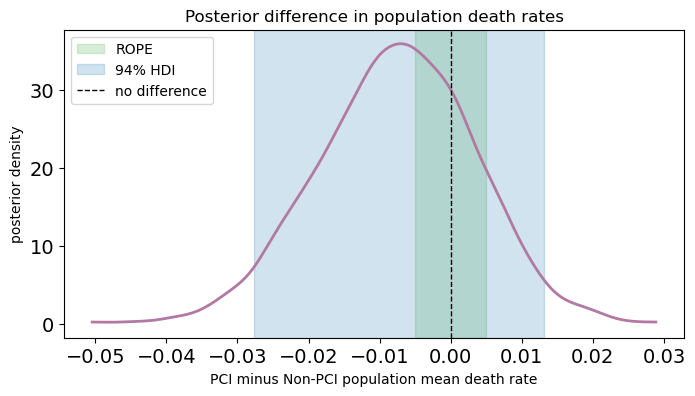

In [221]:
hospital_rate_rope = (-0.005, 0.005)
hospital_difference_samples = hospital_effect_samples["mu_difference"].to_numpy()
hospital_difference_hdi = az.hdi(hospital_difference_samples, hdi_prob=HDI_MASS)
hospital_hdi_overlaps_rope = (
    hospital_difference_hdi[0] <= hospital_rate_rope[1]
    and hospital_difference_hdi[1] >= hospital_rate_rope[0]
)

hospital_rope_summary = pd.DataFrame(
    [
        {
            "parameter": "mu_pci - mu_nonpci",
            "posterior mean": hospital_difference_samples.mean(),
            f"{HDI_MASS:.0%} HDI low": hospital_difference_hdi[0],
            f"{HDI_MASS:.0%} HDI high": hospital_difference_hdi[1],
            "ROPE low": hospital_rate_rope[0],
            "ROPE high": hospital_rate_rope[1],
            "HDI overlaps ROPE": hospital_hdi_overlaps_rope,
            "Pr(difference < 0)": np.mean(hospital_difference_samples < 0),
            "Pr(difference in ROPE)": np.mean(
                (hospital_difference_samples >= hospital_rate_rope[0])
                & (hospital_difference_samples <= hospital_rate_rope[1])
            ),
        }
    ]
)

display(
    hospital_rope_summary.style.format(
        {
            "posterior mean": "{:.4f}",
            f"{HDI_MASS:.0%} HDI low": "{:.4f}",
            f"{HDI_MASS:.0%} HDI high": "{:.4f}",
            "ROPE low": "{:.4f}",
            "ROPE high": "{:.4f}",
            "Pr(difference < 0)": "{:.3f}",
            "Pr(difference in ROPE)": "{:.3f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_kde(
    hospital_difference_samples,
    ax=ax,
    plot_kwargs={"color": HIERARCHICAL_COLOR, "linewidth": 2},
)
ax.axvspan(*hospital_rate_rope, color="tab:green", alpha=0.18, label="ROPE")
ax.axvspan(
    hospital_difference_hdi[0],
    hospital_difference_hdi[1],
    color="tab:blue",
    alpha=0.20,
    label=f"{HDI_MASS:.0%} HDI",
)
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="no difference")
ax.set_xlabel("PCI minus Non-PCI population mean death rate")
ax.set_ylabel("posterior density")
ax.set_title("Posterior difference in population death rates")
ax.legend()
plt.show()


### Frequentist two-proportion z test

The frequentist analogue compares the pooled PCI and Non-PCI death rates with a normal approximation. Under the null hypothesis, both hospital types share one death probability, so the standard error uses the pooled death rate.


Run the frequentist two-proportion z test for PCI versus Non-PCI.


In [228]:
hospital_two_group_counts = (
    hospital_death_data.groupby("Type", observed=False)[["Cases", "Deaths"]]
    .sum()
    .reindex(hospital_type_order)
)
nonpci_deaths = int(hospital_two_group_counts.loc["Non-PCI", "Deaths"])
nonpci_cases = int(hospital_two_group_counts.loc["Non-PCI", "Cases"])
pci_deaths = int(hospital_two_group_counts.loc["PCI", "Deaths"])
pci_cases = int(hospital_two_group_counts.loc["PCI", "Cases"])

nonpci_rate = nonpci_deaths / nonpci_cases
pci_rate = pci_deaths / pci_cases
rate_difference = pci_rate - nonpci_rate
pooled_rate = (pci_deaths + nonpci_deaths) / (pci_cases + nonpci_cases)
standard_error = np.sqrt(
    pooled_rate
    * (1 - pooled_rate)
    * (1 / pci_cases + 1 / nonpci_cases)
)
z_statistic = rate_difference / standard_error
two_sided_p_value = 2 * stats.norm.sf(abs(z_statistic))
one_sided_p_value = stats.norm.cdf(z_statistic)
normal_ci_low = rate_difference - stats.norm.ppf(1 - SIGNIFICANCE_ALPHA / 2) * standard_error
normal_ci_high = rate_difference + stats.norm.ppf(1 - SIGNIFICANCE_ALPHA / 2) * standard_error

hospital_two_proportion_z_test = pd.DataFrame(
    [
        {
            "comparison": "PCI minus Non-PCI",
            "PCI deaths": pci_deaths,
            "PCI cases": pci_cases,
            "PCI rate": pci_rate,
            "Non-PCI deaths": nonpci_deaths,
            "Non-PCI cases": nonpci_cases,
            "Non-PCI rate": nonpci_rate,
            "rate difference": rate_difference,
            "pooled null rate": pooled_rate,
            "standard error": standard_error,
            "z statistic": z_statistic,
            "two-sided p-value": two_sided_p_value,
            "one-sided p-value PCI lower": one_sided_p_value,
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI low": normal_ci_low,
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI high": normal_ci_high,
            f"reject at alpha={SIGNIFICANCE_ALPHA:.2f}": two_sided_p_value < SIGNIFICANCE_ALPHA,
        }
    ]
)

hospital_two_proportion_z_test.style.format(
    {
        "PCI rate": "{:.4f}",
        "Non-PCI rate": "{:.4f}",
        "rate difference": "{:.4f}",
        "pooled null rate": "{:.4f}",
        "standard error": "{:.4f}",
        "z statistic": "{:.2f}",
        "two-sided p-value": "{:.4g}",
        "one-sided p-value PCI lower": "{:.4g}",
        f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI low": "{:.4f}",
        f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI high": "{:.4f}",
    }
)


,comparison,PCI deaths,PCI cases,PCI rate,Non-PCI deaths,Non-PCI cases,Non-PCI rate,rate difference,pooled null rate,standard error,z statistic,two-sided p-value,one-sided p-value PCI lower,94% normal CI low,94% normal CI high,reject at alpha=0.06
0,PCI minus Non-PCI,501,6824,0.0734,197,2411,0.0817,-0.0083,0.0756,0.0063,-1.32,0.1855,0.09275,-0.0201,0.0035,False


### Post-hoc Bayesian power for the two-group rate difference

For a fast post-hoc power calculation, we keep the observed PCI and Non-PCI case totals fixed and simulate aggregate deaths for a grid of true rate differences. Each simulated dataset is fit in one vectorized PyMC model. A simulation counts as detected when the posterior HDI for the difference clears the ROPE in the expected direction.


Simulate aggregate PCI and Non-PCI deaths and fit the vectorized power model.


Simulate group-level hospital counts for the post-hoc power grid.


In [ ]:
HOSPITAL_POWER_NUM_REPS = 100
HOSPITAL_POWER_DRAWS = 500
HOSPITAL_POWER_TUNE = 500
HOSPITAL_POWER_CHAINS = 2
HOSPITAL_POWER_SEED = 917_143
HOSPITAL_POWER_TARGET = 0.90
HOSPITAL_POWER_EFFECT_MAGNITUDES = np.round(np.arange(0.000, 0.041, 0.005), 3)

hospital_group_counts = (
    hospital_death_data.groupby("Type", observed=False)[["Cases", "Deaths"]]
    .sum()
    .reindex(hospital_type_order)
)
hospital_power_cases_by_type = hospital_group_counts["Cases"].to_numpy(dtype=int)
hospital_power_observed_rate_by_type = (
    hospital_group_counts["Deaths"] / hospital_group_counts["Cases"]
).to_numpy()
hospital_power_baseline_nonpci = hospital_power_observed_rate_by_type[0]
hospital_power_direction = np.sign(hospital_difference_samples.mean()) or -1

hospital_power_effect_group = np.repeat(
    HOSPITAL_POWER_EFFECT_MAGNITUDES,
    HOSPITAL_POWER_NUM_REPS,
)
hospital_power_true_nonpci = np.full(
    hospital_power_effect_group.size,
    hospital_power_baseline_nonpci,
)
hospital_power_true_pci = np.clip(
    hospital_power_true_nonpci + hospital_power_direction * hospital_power_effect_group,
    0.001,
    0.999,
)
hospital_power_true_rates = np.column_stack(
    [hospital_power_true_nonpci, hospital_power_true_pci]
)
hospital_power_cases = np.tile(
    hospital_power_cases_by_type,
    (hospital_power_effect_group.size, 1),
)
hospital_power_rng = np.random.default_rng(HOSPITAL_POWER_SEED)
hospital_power_deaths = hospital_power_rng.binomial(
    n=hospital_power_cases,
    p=hospital_power_true_rates,
)


Fit one PyMC model to the hospital post-hoc power grid.


In [ ]:
hospital_power_coords = {
    "simulation": np.arange(hospital_power_effect_group.size),
    "hospital_type": hospital_type_order,
}
with pm.Model(coords=hospital_power_coords) as hospital_power_model:
    hospital_power_mu_type = pm.Beta(
        "hospital_power_mu_type",
        mu=hospital_mu_mu_theta,
        nu=hospital_nu_mu_theta,
        dims=("simulation", "hospital_type"),
    )
    pm.Binomial(
        "hospital_power_deaths",
        n=hospital_power_cases,
        p=hospital_power_mu_type,
        observed=hospital_power_deaths,
        dims=("simulation", "hospital_type"),
    )
    hospital_power_mu_difference = pm.Deterministic(
        "hospital_power_mu_difference",
        hospital_power_mu_type[:, 1] - hospital_power_mu_type[:, 0],
        dims="simulation",
    )
    idata_hospital_power = pm.sample(
        draws=HOSPITAL_POWER_DRAWS,
        tune=HOSPITAL_POWER_TUNE,
        chains=HOSPITAL_POWER_CHAINS,
        cores=1,
        random_seed=HOSPITAL_POWER_SEED,
        target_accept=0.90,
        progressbar=False,
        compute_convergence_checks=False,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": False},
    )


Convert simulated posteriors into HDI/ROPE decisions.


In [ ]:
hospital_power_diff_hdi = az.hdi(
    idata_hospital_power.posterior["hospital_power_mu_difference"],
    hdi_prob=HDI_MASS,
)["hospital_power_mu_difference"].values
hospital_power_hdi_low = hospital_power_diff_hdi[:, 0]
hospital_power_hdi_high = hospital_power_diff_hdi[:, 1]
hospital_power_hdi_width = hospital_power_hdi_high - hospital_power_hdi_low
hospital_power_hdi_overlaps_rope = (
    (hospital_power_hdi_low <= hospital_rate_rope[1])
    & (hospital_power_hdi_high >= hospital_rate_rope[0])
)
if hospital_power_direction < 0:
    hospital_power_detected = hospital_power_hdi_high < hospital_rate_rope[0]
else:
    hospital_power_detected = hospital_power_hdi_low > hospital_rate_rope[1]

hospital_power_rows = []
for effect_magnitude in HOSPITAL_POWER_EFFECT_MAGNITUDES:
    matching = hospital_power_effect_group == effect_magnitude
    hospital_power_rows.append(
        {
            "true absolute difference": effect_magnitude,
            "power: HDI clears ROPE": hospital_power_detected[matching].mean(),
            "HDI overlaps ROPE": hospital_power_hdi_overlaps_rope[matching].mean(),
            f"median {HDI_MASS:.0%} HDI width": np.median(hospital_power_hdi_width[matching]),
            "10% HDI width": np.quantile(hospital_power_hdi_width[matching], 0.10),
            "90% HDI width": np.quantile(hospital_power_hdi_width[matching], 0.90),
        }
    )

hospital_power = pd.DataFrame(hospital_power_rows)
hospital_power_target_candidates = hospital_power.loc[
    hospital_power["power: HDI clears ROPE"] >= HOSPITAL_POWER_TARGET,
    "true absolute difference",
]
hospital_power_first_effect_on_grid = (
    hospital_power_target_candidates.min()
    if len(hospital_power_target_candidates)
    else np.nan
)
hospital_power_summary = pd.DataFrame(
    [
        {
            "analysis": "post hoc Bayesian group-rate grid",
            "Non-PCI cases": hospital_power_cases_by_type[0],
            "PCI cases": hospital_power_cases_by_type[1],
            "target power": HOSPITAL_POWER_TARGET,
            "first absolute difference on grid at target": hospital_power_first_effect_on_grid,
        }
    ]
)


Display the hospital post-hoc power tables.


In [ ]:
display(
    hospital_power_summary.style.format(
        {
            "target power": "{:.2f}",
            "first absolute difference on grid at target": "{:.3f}",
        }
    )
)
display(
    hospital_power.style.format(
        {
            "true absolute difference": "{:.3f}",
            "power: HDI clears ROPE": "{:.3f}",
            "HDI overlaps ROPE": "{:.3f}",
            f"median {HDI_MASS:.0%} HDI width": "{:.4f}",
            "10% HDI width": "{:.4f}",
            "90% HDI width": "{:.4f}",
        }
    )
)


Plot hospital post-hoc power and posterior interval width.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    hospital_power["true absolute difference"],
    hospital_power["power: HDI clears ROPE"],
    marker="o",
    label="HDI clears ROPE",
)
ax.plot(
    hospital_power["true absolute difference"],
    hospital_power["HDI overlaps ROPE"],
    marker="o",
    label="HDI overlaps ROPE",
)
ax.axhline(HOSPITAL_POWER_TARGET, color="tab:red", linestyle="--", label="90% target")
if np.isfinite(hospital_power_first_effect_on_grid):
    ax.axvline(
        hospital_power_first_effect_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid difference={hospital_power_first_effect_on_grid:.3f}",
    )
ax.set_ylim(0, 1.02)
ax.set_xlabel("true absolute difference in population death rates")
ax.set_ylabel("simulation proportion")
ax.set_title("Post-hoc Bayesian power for PCI versus Non-PCI")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    hospital_power["true absolute difference"],
    hospital_power[f"median {HDI_MASS:.0%} HDI width"],
    marker="o",
)
ax.fill_between(
    hospital_power["true absolute difference"],
    hospital_power["10% HDI width"],
    hospital_power["90% HDI width"],
    alpha=0.20,
    label="middle 80% of simulated widths",
)
if np.isfinite(hospital_power_first_effect_on_grid):
    ax.axvline(hospital_power_first_effect_on_grid, color="black", linestyle=":")
ax.set_xlabel("true absolute difference in population death rates")
ax.set_ylabel(f"{HDI_MASS:.0%} HDI width")
ax.set_title("Posterior interval width across true two-group effects")
ax.legend()
plt.show()


### Pre-hoc precision analysis for the two-group difference

A different planning question is not whether we can reject a hypothesis, but how many hospitals we need before the posterior interval for the PCI versus Non-PCI population difference is narrow enough. Here we use the fitted hospital model as a generator for plausible hospital death probabilities. For each planned number of hospitals per group, we draw PCI and Non-PCI hospital-level probabilities from the posterior population distributions, fit a top-level model to those probabilities, and measure the HDI width of the difference in group means.


Simulate hospital-level probabilities and fit top-level models for each planned hospital count.


Set up posterior draws for the hospital pre-hoc precision simulation.


In [ ]:
HOSPITAL_PRE_HOC_NUM_REPS = 100
HOSPITAL_PRE_HOC_DRAWS = 500
HOSPITAL_PRE_HOC_TUNE = 500
HOSPITAL_PRE_HOC_CHAINS = 2
HOSPITAL_PRE_HOC_SEED = 1_017_143
HOSPITAL_PRE_HOC_TARGET_HDI_WIDTH = 0.0005
HOSPITAL_PRE_HOC_GROUP_SIZES = np.array([5, 8, 12, 18, 26, 40, 60, 90, 130, 190, 280])

hospital_pre_hoc_rng = np.random.default_rng(HOSPITAL_PRE_HOC_SEED)
hospital_population_samples = az.extract(
    idata_hospital_type,
    var_names=["mu_type", "nu_type"],
    combined=True,
)
hospital_population_sample_idx = hospital_pre_hoc_rng.integers(
    0,
    hospital_population_samples.sizes["sample"],
    size=HOSPITAL_PRE_HOC_NUM_REPS,
)


Fit each planned hospital count and collect HDI widths.


Define a helper that simulates hospital-level rates from the posterior.


In [ ]:
def simulate_hospital_type_thetas(planned_n):
    simulated_theta = np.empty((HOSPITAL_PRE_HOC_NUM_REPS, 2, planned_n))
    for repetition_idx, posterior_idx in enumerate(hospital_population_sample_idx):
        mu_sample = hospital_population_samples["mu_type"].isel(sample=posterior_idx).to_numpy()
        nu_sample = hospital_population_samples["nu_type"].isel(sample=posterior_idx).to_numpy()
        alpha_sample = mu_sample * nu_sample
        beta_sample = (1 - mu_sample) * nu_sample
        simulated_theta[repetition_idx, 0, :] = hospital_pre_hoc_rng.beta(
            alpha_sample[0],
            beta_sample[0],
            size=planned_n,
        )
        simulated_theta[repetition_idx, 1, :] = hospital_pre_hoc_rng.beta(
            alpha_sample[1],
            beta_sample[1],
            size=planned_n,
        )
    return simulated_theta


Fit each planned hospital count and collect HDI widths.


In [ ]:
hospital_pre_hoc_width_rows = []
for planned_n in HOSPITAL_PRE_HOC_GROUP_SIZES:
    hospital_pre_hoc_theta = simulate_hospital_type_thetas(planned_n)

    hospital_pre_hoc_coords = {
        "simulation": np.arange(HOSPITAL_PRE_HOC_NUM_REPS),
        "hospital_type": hospital_type_order,
        "planned_hospital": np.arange(planned_n),
    }
    with pm.Model(coords=hospital_pre_hoc_coords) as hospital_pre_hoc_model:
        pre_hoc_mu_type = pm.Beta(
            "pre_hoc_mu_type",
            mu=hospital_mu_mu_theta,
            nu=hospital_nu_mu_theta,
            dims=("simulation", "hospital_type"),
        )
        pre_hoc_nu_type = pm.HalfNormal(
            "pre_hoc_nu_type",
            sigma=hospital_sigma_nu_theta,
            dims=("simulation", "hospital_type"),
        )
        pm.Beta(
            "pre_hoc_theta",
            mu=pre_hoc_mu_type[:, :, None],
            nu=pre_hoc_nu_type[:, :, None],
            observed=hospital_pre_hoc_theta,
            dims=("simulation", "hospital_type", "planned_hospital"),
        )
        pre_hoc_mu_difference = pm.Deterministic(
            "pre_hoc_mu_difference",
            pre_hoc_mu_type[:, 1] - pre_hoc_mu_type[:, 0],
            dims="simulation",
        )
        idata_hospital_pre_hoc = pm.sample(
            draws=HOSPITAL_PRE_HOC_DRAWS,
            tune=HOSPITAL_PRE_HOC_TUNE,
            chains=HOSPITAL_PRE_HOC_CHAINS,
            cores=1,
            random_seed=HOSPITAL_PRE_HOC_SEED + int(planned_n),
            target_accept=0.90,
            progressbar=False,
            compute_convergence_checks=False,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": False},
        )

    hospital_pre_hoc_hdi = az.hdi(
        idata_hospital_pre_hoc.posterior["pre_hoc_mu_difference"],
        hdi_prob=HDI_MASS,
    )["pre_hoc_mu_difference"].values
    hospital_pre_hoc_hdi_width = hospital_pre_hoc_hdi[:, 1] - hospital_pre_hoc_hdi[:, 0]

    hospital_pre_hoc_width_rows.append(
        {
            "hospitals per group": planned_n,
            f"median {HDI_MASS:.0%} HDI width": np.median(hospital_pre_hoc_hdi_width),
            "10% HDI width": np.quantile(hospital_pre_hoc_hdi_width, 0.10),
            "90% HDI width": np.quantile(hospital_pre_hoc_hdi_width, 0.90),
            "Pr(width <= target)": np.mean(
                hospital_pre_hoc_hdi_width <= HOSPITAL_PRE_HOC_TARGET_HDI_WIDTH
            ),
        }
    )


Summarize HDI width for each planned number of hospitals.


In [ ]:
hospital_pre_hoc_precision = pd.DataFrame(hospital_pre_hoc_width_rows)
hospital_pre_hoc_target_candidates = hospital_pre_hoc_precision.loc[
    hospital_pre_hoc_precision[f"median {HDI_MASS:.0%} HDI width"]
    <= HOSPITAL_PRE_HOC_TARGET_HDI_WIDTH,
    "hospitals per group",
]
hospital_pre_hoc_first_n_on_grid = (
    hospital_pre_hoc_target_candidates.min()
    if len(hospital_pre_hoc_target_candidates)
    else np.nan
)
hospital_pre_hoc_precision_summary = pd.DataFrame(
    [
        {
            "analysis": "pre hoc HDI precision grid",
            "target HDI width": HOSPITAL_PRE_HOC_TARGET_HDI_WIDTH,
            "first hospitals per group on grid at target": hospital_pre_hoc_first_n_on_grid,
            "simulations per grid point": HOSPITAL_PRE_HOC_NUM_REPS,
        }
    ]
)

display(
    hospital_pre_hoc_precision_summary.style.format(
        {
            "target HDI width": "{:.4f}",
            "first hospitals per group on grid at target": "{:.0f}",
        }
    )
)
display(
    hospital_pre_hoc_precision.style.format(
        {
            f"median {HDI_MASS:.0%} HDI width": "{:.4f}",
            "10% HDI width": "{:.4f}",
            "90% HDI width": "{:.4f}",
            "Pr(width <= target)": "{:.3f}",
        }
    )
)


Plot HDI width against the planned number of hospitals per group.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    hospital_pre_hoc_precision["hospitals per group"],
    hospital_pre_hoc_precision[f"median {HDI_MASS:.0%} HDI width"],
    marker="o",
    label="median HDI width",
)
ax.fill_between(
    hospital_pre_hoc_precision["hospitals per group"],
    hospital_pre_hoc_precision["10% HDI width"],
    hospital_pre_hoc_precision["90% HDI width"],
    alpha=0.20,
    label="middle 80% of simulated widths",
)
ax.axhline(
    HOSPITAL_PRE_HOC_TARGET_HDI_WIDTH,
    color="tab:red",
    linestyle="--",
    label="0.05 percentage point target",
)
if np.isfinite(hospital_pre_hoc_first_n_on_grid):
    ax.axvline(
        hospital_pre_hoc_first_n_on_grid,
        color="black",
        linestyle=":",
        label=rf"first grid $N={hospital_pre_hoc_first_n_on_grid:.0f}$ per group",
    )
ax.set_xscale("log")
ax.set_xlabel("planned hospitals per group")
ax.set_ylabel(f"{HDI_MASS:.0%} HDI width for PCI minus Non-PCI mean")
ax.set_title("Pre-hoc precision for the two-group hospital comparison")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    hospital_pre_hoc_precision["hospitals per group"],
    hospital_pre_hoc_precision["Pr(width <= target)"],
    marker="o",
)
ax.axhline(0.90, color="tab:red", linestyle="--", label="90% of simulations")
if np.isfinite(hospital_pre_hoc_first_n_on_grid):
    ax.axvline(hospital_pre_hoc_first_n_on_grid, color="black", linestyle=":")
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_xlabel("planned hospitals per group")
ax.set_ylabel("simulation proportion")
ax.set_title("How often does the HDI width meet the target?")
ax.legend()
plt.show()
